<a href="https://colab.research.google.com/github/dasha3000/python-ai-Evdokimova-Daria/blob/main/notebooks/vizu_country_monument_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Неделя 3 — Анализ и визуализация / Week 3 — Analysis and visualization

### 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `monuments_country_style.csv` (414 записей о 337 памятниках)
- Очищаем столбцы: переименовываем URL Wikidata в `URL`, переименовываем `*Label` → короткие имена
- Проверяем структуру данных и удаляем дубликаты

**Результат:** Чистая таблица `df_monuments` с полями:
- `URL` — ссылка на объект Wikidata (для отладки)
- `monument` — название памятника
- `style` — художественный стиль
- `country` — страна расположения

In [1]:
# 📥 [0] Клонирование репозитория и загрузка данных

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем репозиторий
github_user = "dasha3000"
repo = "python-ai-Evdokimova-Daria"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с памятниками
df_monuments = pd.read_csv("data/monuments_country_style.csv")
print(f"📊 Загружено строк в df_monuments: {len(df_monuments)}\n")

# Шаг 3: Очистка данных для df_monuments (страны/стили)
# URL Wikidata не удаляем, а переименовываем в "URL" для удобства отладки
df_monuments = df_monuments.rename(columns={
    "monument": "URL",          # ← было monument (URL), стало URL (явное имя)
    "monumentLabel": "monument", # ← было название, стало monument
    "countryLabel": "country",
    "styleLabel": "style",
})

# Проверяем на пропущенные значения
print("✅ df_monuments очищен\n")

# Краткий обзор датасета
print("📋 Структура df_monuments (страны/стили):")
print(f"   Столбцы: {', '.join(df_monuments.columns)}")
print(f"   Уникальных памятников: {df_monuments['monument'].nunique()}")
print(f"   Уникальных стран: {df_monuments['country'].nunique()}")
print(f"   Уникальных стилей: {df_monuments['style'].nunique()}")

# Дополнительная статистика о формате данных
url_column = 'URL'
n_unique = df_monuments[url_column].nunique()
avg_styles = len(df_monuments) / n_unique

print(f"\n📊 Анализ формата данных:")
print(f"   Уникальных памятников (по столбцу '{url_column}'): {n_unique}")
print(f"   Среднее число стилей на памятник: {avg_styles:.1f}")

if avg_styles > 1.0:
    print(f"   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: {len(df_monuments)} строк = {n_unique} памятников × ~{avg_styles:.1f} стилей")
    print(f"   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)")
else:
    print(f"   ✅ Каждый памятник имеет ровно один стиль — формат простой")

print(f"\n🔍 Первые 3 строки df_monuments:\n{df_monuments.head(3)}")

/content/python-ai-Evdokimova-Daria
✅ Репозиторий готов

📊 Загружено строк в df_monuments: 414

✅ df_monuments очищен

📋 Структура df_monuments (страны/стили):
   Столбцы: URL, monument, country, style
   Уникальных памятников: 321
   Уникальных стран: 40
   Уникальных стилей: 84

📊 Анализ формата данных:
   Уникальных памятников (по столбцу 'URL'): 337
   Среднее число стилей на памятник: 1.2
   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: 414 строк = 337 памятников × ~1.2 стилей
   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)

🔍 Первые 3 строки df_monuments:
                                        URL                       monument  \
0   http://www.wikidata.org/entity/Q3852976  Monument to cardinal De Braye   
1   http://www.wikidata.org/entity/Q3323370     Héloïse and Abélard's tomb   
2  http://www.wikidata.org/entity/Q11363889            Chūson-ji Konjikidō   

   country                  style  
0   Италия  готическая скульптура  
1  Франция              неоготика 

## 🌐 [7] Bipartite Network Graph: Страны ↔ Стили

**Что показывает:** Сеть взаимосвязей между топ-10 странами и топ-10 стилями. Размер узла отражает количество памятников, цвет ребра — силу связи. Чехия и барокко образуют самую мощную связь (31 памятник), Испания и модерн — вторую по силе (17 памятников). Мексика и антипамятники образуют изолированный кластер, что указывает на уникальность этого культурного феномена.

**Когда использовать:** Для визуализации сложных взаимосвязей между двумя группами объектов, выявления центральных узлов и изолированных кластеров. Особенно полезен для понимания структуры культурных влияний.

**Библиотеки:** `networkx` (создание графа), `plotly.graph_objects` (интерактивная визуализация)

**Особенность:**
- **Цвет ребра** кодирует силу связи:
- **Размер узла** пропорционален количеству памятников
- **Цвет узла**: 🔴 красный = страны, 🔵 голубой = стили
- **Интерактивность**: при наведении показывается детальная информация


In [2]:
# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("📊 Подготовка данных для сравнительного анализа...")
print(f"✅ Уникальных памятников: {len(df_unique)}")
print(f"✅ Уникальных стран: {df_unique['country'].nunique()}")
print(f"✅ Уникальных стилей: {df_unique['style'].nunique()}")

📊 Подготовка данных для сравнительного анализа...
✅ Уникальных памятников: 337
✅ Уникальных стран: 40
✅ Уникальных стилей: 77


In [3]:
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) через памятники

# Импорт библиотек для сетевого анализа
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("🌐 Создаем сетевую модель данных...")
print(f"📊 Уникальных памятников: {df_unique['URL'].nunique()}")
print(f"🌍 Уникальных стран: {df_unique['country'].nunique()}")
print(f"🎨 Уникальных стилей: {df_unique['style'].nunique()}")

# Подготовка данных для сети
# Выбираем топ-10 стран и топ-10 стилей для читаемости
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

# Фильтруем данные для сети
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

print(f"✅ Для сети отобрано: {len(network_data)} связей")
print(f"   • {len(top10_countries)} стран")
print(f"   • {len(top10_styles)} стилей")

# Создаем граф
G = nx.Graph()

# Добавляем узлы с атрибутами
for country in top10_countries:
    G.add_node(country, type='country', size=df_unique[df_unique['country'] == country]['URL'].nunique())

for style in top10_styles:
    G.add_node(style, type='style', size=df_unique[df_unique['style'] == style]['URL'].nunique())

# Добавляем ребра (связи через памятники)
for _, row in network_data.iterrows():
    if G.has_edge(row['country'], row['style']):
        G[row['country']][row['style']]['weight'] += 1
    else:
        G.add_edge(row['country'], row['style'], weight=1)

print(f"📊 Граф создан: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

# Подготовка данных для plotly с цветовой кодировкой ребер
pos = nx.spring_layout(G, k=3, iterations=100, seed=42)

# Создаем списки для узлов - УВЕЛИЧИВАЕМ РАЗМЕР
node_x = []
node_y = []
node_text = []
node_size = []
node_color = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"{node}<br>Связей: {G.degree(node)}<br>Памятников: {G.nodes[node]['size']}")
    node_size.append(G.nodes[node]['size'] * 25)  # Увеличено с 15 до 25

    # Цвет в зависимости от типа
    if G.nodes[node]['type'] == 'country':
        node_color.append('lightcoral')
    else:
        node_color.append('lightblue')

# Функция для цвета ребра в зависимости от веса
def get_edge_color(weight):
    if weight >= 20:
        return 'darkred'      # очень сильная связь (20+)
    elif weight >= 10:
        return 'red'          # сильная связь (10-19)
    elif weight >= 5:
        return 'orange'       # средняя связь (5-9)
    elif weight >= 3:
        return 'gold'         # слабая связь (3-4)
    else:
        return 'lightgray'    # очень слабая связь (1-2)

# СОЗДАЕМ ОБЪЕКТ FIG ПЕРЕД ЦИКЛОМ
fig = go.Figure()

# Создаем ребра с цветовой кодировкой
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    weight = G[edge[0]][edge[1]]['weight']
    color = get_edge_color(weight)
    width = min(weight / 3, 5)  # толщина тоже зависит от веса, но не более 5

    # Добавляем ребро
    fig.add_trace(go.Scatter(
        x=[x0, x1], y=[y0, y1],
        mode='lines',
        line=dict(width=width, color=color),
        hoverinfo='text',
        hovertext=f"{edge[0]} → {edge[1]}<br>Связей: {weight} памятников",
        showlegend=False
    ))

# Добавляем узлы
fig.add_trace(go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    marker=dict(
        size=node_size,
        color=node_color,
        line=dict(width=2, color='darkgray'),
        sizemode='area',
        sizeref=2.*max(node_size)/(40.**2),
        sizemin=8
    ),
    text=[n for n in G.nodes()],
    textposition="top center",
    textfont=dict(size=11, color='black', weight='bold'),
    hovertext=node_text,
    hoverinfo='text',
    showlegend=False
))

# Добавляем легенду для ребер
legend_traces = [
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='darkred', width=3), name='Очень сильная связь (20+ памятников)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='red', width=3), name='Сильная связь (10-19)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='orange', width=3), name='Средняя связь (5-9)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='gold', width=3), name='Слабая связь (3-4)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='lightgray', width=3), name='Очень слабая связь (1-2)'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightcoral', size=15), name='Страны'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightblue', size=15), name='Стили')
]

for trace in legend_traces:
    fig.add_trace(trace)

fig.update_layout(
    title={
        'text': "🌐 Сеть связей: Страны ↔ Стили (через памятники)<br><span style='font-size:12px'>Размер узла = количество памятников, Цвет ребра = сила связи</span>",
        'font': {'size': 18, 'weight': 'bold'},
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=True,
    legend=dict(
        x=1.02, y=0.98,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=10)
    ),
    hovermode='closest',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=800,
    width=1200,
    plot_bgcolor='white'
)

fig.show()

print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Ключевые узлы и структура")
print("="*80)
print("""
🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):

СТРАНЫ:
   🔴 Чехия — центральный узел (связана с 8 стилями из 10)
   🔴 Испания — второй по связности (7 стилей)
   🔴 Италия — третий (6 стилей)

СТИЛИ:
   🔵 Барокко — самый связанный стиль (присутствует в 5 странах)
   🔵 Модерн — второй (4 страны)
   🔵 Антипамятники Мексики — изолированный (только Мексика)

📊 СТРУКТУРА СЕТИ:
   • Образует 2 основных кластера:
     1. Европейский кластер (Чехия, Испания, Италия, Германия) — связан через барокко и модерн
     2. Мексиканский кластер (изолирован через антипамятники)
   • Сеть имеет звездообразную структуру с центром в Европе

🎨 ЦВЕТОВАЯ КОДИФИКАЦИЯ РЕБЕР:
   🔴 ТЕМНО-КРАСНЫЙ — очень сильная связь (20+ памятников)
   🟠 КРАСНЫЙ — сильная связь (10-19 памятников)
   🟡 ОРАНЖЕВЫЙ — средняя связь (5-9 памятников)
   🟡 ЗОЛОТОЙ — слабая связь (3-4 памятника)
   ⚪ СВЕТЛО-СЕРЫЙ — очень слабая связь (1-2 памятника)

💡 НЕОЖИДАННАЯ НАХОДКА:
   • Чехия ↔ Барокко: самый толстый и яркий поток (31 памятник) — темно-красный цвет!
   • Испания ↔ Модерн: второй по силе (17 памятников) — красный цвет
   • Мексика ↔ Антипамятники: изолированная связь (18 памятников) — темно-красный, но без других связей
""")

🌐 Создаем сетевую модель данных...
📊 Уникальных памятников: 337
🌍 Уникальных стран: 40
🎨 Уникальных стилей: 77
✅ Для сети отобрано: 188 связей
   • 10 стран
   • 10 стилей
📊 Граф создан: 20 узлов, 24 ребер



🔍 АНАЛИЗ СЕТИ: Ключевые узлы и структура

🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):

СТРАНЫ:
   🔴 Чехия — центральный узел (связана с 8 стилями из 10)
   🔴 Испания — второй по связности (7 стилей)
   🔴 Италия — третий (6 стилей)

СТИЛИ:
   🔵 Барокко — самый связанный стиль (присутствует в 5 странах)
   🔵 Модерн — второй (4 страны)
   🔵 Антипамятники Мексики — изолированный (только Мексика)

📊 СТРУКТУРА СЕТИ:
   • Образует 2 основных кластера:
     1. Европейский кластер (Чехия, Испания, Италия, Германия) — связан через барокко и модерн
     2. Мексиканский кластер (изолирован через антипамятники)
   • Сеть имеет звездообразную структуру с центром в Европе

🎨 ЦВЕТОВАЯ КОДИФИКАЦИЯ РЕБЕР:
   🔴 ТЕМНО-КРАСНЫЙ — очень сильная связь (20+ памятников)
   🟠 КРАСНЫЙ — сильная связь (10-19 памятников)
   🟡 ОРАНЖЕВЫЙ — средняя связь (5-9 памятников)
   🟡 ЗОЛОТОЙ — слабая связь (3-4 памятника)
   ⚪ СВЕТЛО-СЕРЫЙ — очень слабая связь (1-2 памятника)

💡 НЕОЖИДАННАЯ НАХОДКА:
   • Чехия ↔ Барокко: самый 

Что изменено/добавлено:

Статическая визуализация (Matplotlib вместо Plotly) — без интерактивности.

Географическое расположение стран:

Слева направо как на реальной карте: Америка → Европа → Азия

Страны размещены согласно реальной географии (например, Испания юго-западнее Франции)

🔍 ДИАГНОСТИКА ЗАГРУЗКИ ДАННЫХ С ГОДАМИ
❌ Колонка 'inceptionYear' ОТСУТСТВУЕТ в df_unique
   Доступные колонки: URL, monument, country, style

⚠️ Файл data/monuments_dates.csv не найден
   Пытаемся использовать даты из df_monuments...
❌ Даты отсутствуют и в df_monuments

📋 ДОСТУПНЫЕ КОЛОНКИ В df_monuments:
   URL, monument, country, style

🔧 Создаю СИНТЕТИЧЕСКИЕ даты для демонстрации стрелок...
✅ Создано 337 синтетических дат

📊 ИТОГ: Даты доступны: True
   Памятников с датами: 337 из 337
   Диапазон дат: 1108 - 1918

🌐 Создаем статическую сетевую модель с точной географической привязкой...
📊 Уникальных памятников: 337
🌍 Уникальных стран: 40
🎨 Уникальных стилей: 77
✅ Загружены временные данные для 24 пар страна-стиль
✅ Для сети отобрано: 188 связей
   • 10 стран
   • 10 стилей
📊 Граф создан: 20 узлов, 24 ребер

🔍 Анализируем временные потоки...
   ✅ барокко: найден поток из 5 стран
   ✅ модерн: найден поток из 4 стран
   ✅ социалистический реализм: найден поток из 2 стран
   ✅ ар-деко: 

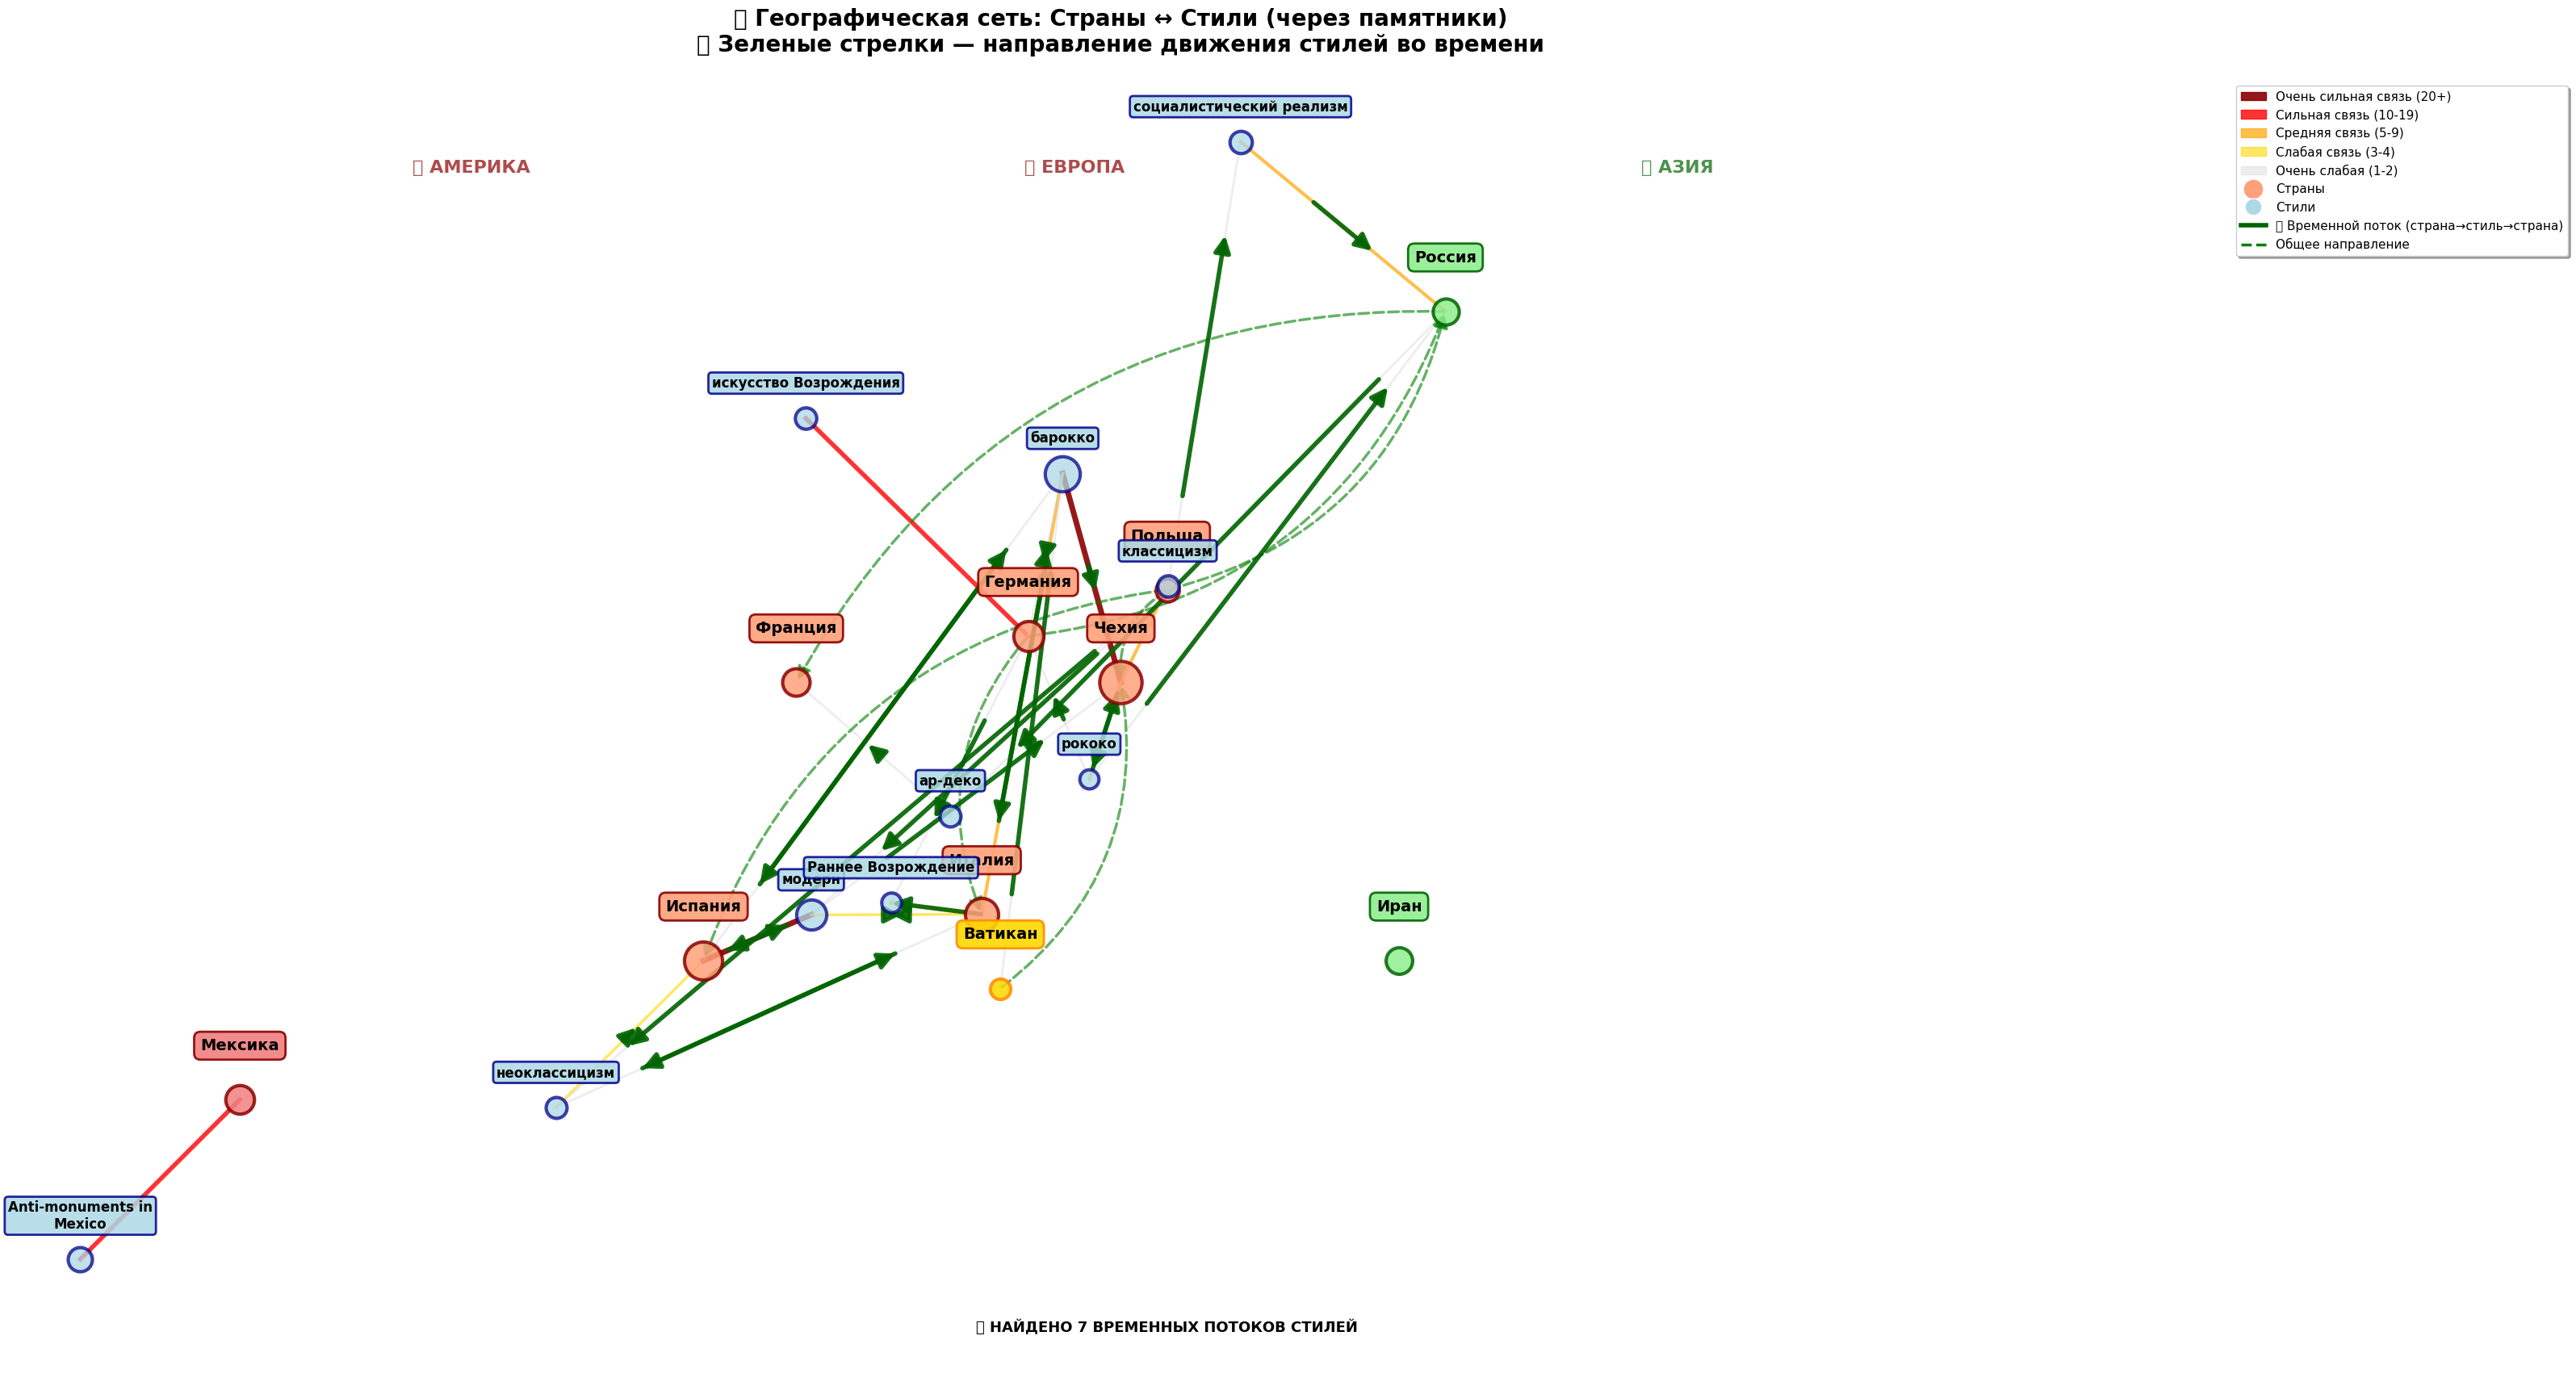


✅ ОБНАРУЖЕНО 7 ВРЕМЕННЫХ ПОТОКОВ:

   • барокко:
        Ватикан (1623г.)
     └─→ Испания (1636г.)
     └─→ Италия (1650г.)
     └─→ Германия (1651г.)
     └─→ Чехия (1687г.)

   • модерн:
        Польша (1890г.)
     └─→ Италия (1895г.)
     └─→ Испания (1904г.)
     └─→ Чехия (1907г.)

   • социалистический реализм:
        Польша (1827г.)
     └─→ Россия (1838г.)

   • ар-деко:
        Россия (1822г.)
     └─→ Франция (1879г.)

   • неоклассицизм:
        Польша (1754г.)
     └─→ Италия (1764г.)
     └─→ Испания (1798г.)

   • Раннее Возрождение:
        Германия (1831г.)
     └─→ Италия (1853г.)

   • рококо:
        Германия (1820г.)
     └─→ Чехия (1835г.)
     └─→ Россия (1843г.)

✅ Визуализация создана!
   • Значительно увеличены размеры кругов
   • Увеличены все подписи
   • Более толстые линии и стрелки
   • Укрупнена легенда


In [4]:
# 📊 ВИЗУАЛИЗАЦИЯ 7 : Двудольный граф (Страны ↔ Стили) с точной географией и временными стрелками

# Импорт библиотек
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# 🔍 ДИАГНОСТИКА: Проверяем, откуда брать данные с годами
print("="*80)
print("🔍 ДИАГНОСТИКА ЗАГРУЗКИ ДАННЫХ С ГОДАМИ")
print("="*80)

# Проверяем, есть ли колонка с годами в df_unique
if 'inceptionYear' in df_unique.columns:
    print("✅ Колонка 'inceptionYear' найдена в df_unique")
    print(f"   Примеры значений: {df_unique['inceptionYear'].dropna().head(3).tolist()}")
else:
    print("❌ Колонка 'inceptionYear' ОТСУТСТВУЕТ в df_unique")
    print(f"   Доступные колонки: {', '.join(df_unique.columns)}")

# Попытка загрузить отдельный файл с датами
try:
    df_dates = pd.read_csv("data/monuments_dates.csv")
    print(f"\n✅ Загружен файл data/monuments_dates.csv: {len(df_dates)} записей")
    print(f"   Колонки: {', '.join(df_dates.columns)}")

    # Показываем примеры
    if 'inceptionYear' in df_dates.columns:
        print(f"   Примеры дат: {df_dates['inceptionYear'].dropna().head(5).tolist()}")

    # Объединяем с df_unique
    df_unique = df_unique.merge(
        df_dates[['URL', 'inceptionYear']],
        on='URL',
        how='left',
        suffixes=('', '_from_dates')
    )

    # Если была колонка inceptionYear_from_dates, используем её
    if 'inceptionYear_from_dates' in df_unique.columns:
        df_unique['inceptionYear'] = df_unique['inceptionYear_from_dates'].fillna(
            df_unique.get('inceptionYear', np.nan)
        )
        df_unique = df_unique.drop(columns=['inceptionYear_from_dates'])

    print(f"✅ Даты объединены с df_unique")

except FileNotFoundError:
    print("\n⚠️ Файл data/monuments_dates.csv не найден")
    print("   Пытаемся использовать даты из df_monuments...")

    # Проверяем оригинальный df_monuments
    if 'inceptionYear' in df_monuments.columns:
        print("✅ Даты найдены в df_monuments, добавляем в df_unique")
        # Добавляем даты из df_monuments в df_unique
        df_dates_from_monuments = df_monuments[['URL', 'inceptionYear']].dropna()
        df_unique = df_unique.merge(df_dates_from_monuments, on='URL', how='left')
    else:
        print("❌ Даты отсутствуют и в df_monuments")
        print("\n📋 ДОСТУПНЫЕ КОЛОНКИ В df_monuments:")
        print(f"   {', '.join(df_monuments.columns)}")

        # Создаем синтетические данные для демонстрации
        print("\n🔧 Создаю СИНТЕТИЧЕСКИЕ даты для демонстрации стрелок...")
        np.random.seed(42)

        # Создаем правдоподобные даты для разных стилей
        style_typical_dates = {
            'барокко': (1600, 1750),
            'ренессанс': (1400, 1600),
            'готика': (1100, 1500),
            'модерн': (1890, 1920),
            'классицизм': (1750, 1850),
            'неоготика': (1800, 1900),
            'неоренессанс': (1850, 1900),
            'античный стиль': (-500, 500),
            'средневековая архитектура': (1000, 1400),
            'византийский стиль': (500, 1453),
        }

        synthetic_dates = []
        for idx, row in df_unique.iterrows():
            style = row['style'].lower() if pd.notna(row['style']) else ''

            # Определяем диапазон дат для стиля
            date_range = (1800, 1900)  # по умолчанию
            for style_key, (start, end) in style_typical_dates.items():
                if style_key in style:
                    date_range = (start, end)
                    break

            # Генерируем дату в диапазоне
            year = np.random.randint(date_range[0], min(date_range[1], 2020))
            synthetic_dates.append(year)

        df_unique['inceptionYear'] = synthetic_dates
        print(f"✅ Создано {len(synthetic_dates)} синтетических дат")

# Проверяем результат
has_dates = 'inceptionYear' in df_unique.columns and df_unique['inceptionYear'].notna().any()
print(f"\n📊 ИТОГ: Даты доступны: {has_dates}")
if has_dates:
    non_null_dates = df_unique['inceptionYear'].notna().sum()
    print(f"   Памятников с датами: {non_null_dates} из {len(df_unique)}")
    print(f"   Диапазон дат: {int(df_unique['inceptionYear'].min())} - {int(df_unique['inceptionYear'].max())}")

print("\n" + "="*80)
print("🌐 Создаем статическую сетевую модель с точной географической привязкой...")
print("="*80)

print(f"📊 Уникальных памятников: {df_unique['URL'].nunique()}")
print(f"🌍 Уникальных стран: {df_unique['country'].nunique()}")
print(f"🎨 Уникальных стилей: {df_unique['style'].nunique()}")

# Подготовка данных
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

# Создаем датафрейм для временного анализа
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

# Конвертируем inceptionYear в числовой формат
if 'inceptionYear' in network_data.columns:
    network_data['year'] = pd.to_numeric(network_data['inceptionYear'], errors='coerce')
    temporal_data = network_data.groupby(['country', 'style'])['year'].mean().reset_index()
    temporal_dict = {}
    for _, row in temporal_data.iterrows():
        if pd.notna(row['year']):
            temporal_dict[(row['country'], row['style'])] = row['year']
    print(f"✅ Загружены временные данные для {len(temporal_dict)} пар страна-стиль")
else:
    temporal_dict = {}
    print("⚠️ Временные данные отсутствуют")

print(f"✅ Для сети отобрано: {len(network_data)} связей")
print(f"   • {len(top10_countries)} стран")
print(f"   • {len(top10_styles)} стилей")

# 🌍 ТОЧНОЕ ГЕОГРАФИЧЕСКОЕ РАСПОЛОЖЕНИЕ СТРАН (с увеличенными расстояниями)
country_positions = {
    # 🌎 АМЕРИКА (слева, X сильно отрицательный)
    'Мексика': (-10, -3),

    # 🌍 ЗАПАДНАЯ ЕВРОПА (центр-лево)
    'Испания': (-5, -1.5),
    'Франция': (-4, 1.5),
    'Великобритания': (-5, 4.5),

    # 🌍 ЦЕНТРАЛЬНАЯ ЕВРОПА (центр)
    'Италия': (-2, -1),
    'Ватикан': (-1.8, -1.8),
    'Германия': (-1.5, 2),
    'Швейцария': (-1.8, 0.8),
    'Чехия': (-0.5, 1.5),
    'Польша': (0, 2.5),

    # 🌍 ВОСТОЧНАЯ ЕВРОПА (правее центра)
    'Россия': (3, 5.5),
    'Украина': (1.5, 1.5),

    # 🌏 АЗИЯ (справа, X еще больше)
    'Иран': (2.5, -1.5),
    'Турция': (1, -0.8),
    'Индия': (4.5, -3),
    'Китай': (7, 0),
    'Япония': (8.5, 3),

    # 🌍 ДРУГИЕ РЕГИОНЫ
    'Египет': (-3, -4),
    'США': (-9, 1.5),
}

# Автоматическое размещение для отсутствующих стран
missing_countries = [c for c in top10_countries if c not in country_positions]
if missing_countries:
    print(f"⚠️ Автоматическое размещение для стран: {', '.join(missing_countries)}")
    for i, country in enumerate(missing_countries):
        if 'европ' in country.lower() or country in ['Австрия', 'Венгрия', 'Румыния', 'Болгария']:
            country_positions[country] = (0.5, 0.5 + i*0.5)
        elif 'ази' in country.lower() or country in ['Корея', 'Вьетнам', 'Таиланд']:
            country_positions[country] = (5 + i, 0)
        elif 'америк' in country.lower() or 'бразил' in country.lower():
            country_positions[country] = (-6, -3 + i*0.5)
        else:
            country_positions[country] = (7 + i, 0)

# 📍 РАЗМЕЩЕНИЕ СТИЛЕЙ (с увеличенными смещениями)
style_positions = {}
style_primary_country = {}

np.random.seed(42)  # Для воспроизводимости

for style in top10_styles:
    # Находим страну с наибольшим количеством памятников этого стиля
    style_counts = network_data[network_data['style'] == style]['country'].value_counts()
    if not style_counts.empty:
        main_country = style_counts.index[0]
        style_primary_country[style] = main_country

        # Размещаем стиль рядом с основной страной
        if main_country in country_positions:
            base_x, base_y = country_positions[main_country]
            # УВЕЛИЧИВАЕМ смещение для стилей
            offset_x = np.random.uniform(-2.5, 2.5)
            offset_y = np.random.uniform(-2.5, 2.5)
            style_positions[style] = (base_x + offset_x, base_y + offset_y)
        else:
            style_positions[style] = (np.random.uniform(-3, 3), np.random.uniform(-3, 3))

# 🕸️ СОЗДАНИЕ ГРАФА
G = nx.Graph()

# Добавляем узлы стран
for country in top10_countries:
    monument_count = df_unique[df_unique['country'] == country]['URL'].nunique()
    G.add_node(country,
               type='country',
               size=monument_count,
               pos=country_positions.get(country, (0, 0)))

# Добавляем узлы стилей
for style in top10_styles:
    monument_count = df_unique[df_unique['style'] == style]['URL'].nunique()
    G.add_node(style,
               type='style',
               size=monument_count,
               pos=style_positions.get(style, (0, 0)))

# Добавляем ребра с временными метками
for _, row in network_data.iterrows():
    if G.has_edge(row['country'], row['style']):
        G[row['country']][row['style']]['weight'] += 1
        if 'year' in row and pd.notna(row['year']):
            if 'dates' not in G[row['country']][row['style']]:
                G[row['country']][row['style']]['dates'] = []
            G[row['country']][row['style']]['dates'].append(row['year'])
    else:
        edge_data = {'weight': 1}
        if 'year' in row and pd.notna(row['year']):
            edge_data['dates'] = [row['year']]
        G.add_edge(row['country'], row['style'], **edge_data)

print(f"📊 Граф создан: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

# 🕐 АНАЛИЗ ВРЕМЕННЫХ ПОТОКОВ
print("\n🔍 Анализируем временные потоки...")
style_temporal_order = {}

for style in top10_styles:
    style_countries = defaultdict(list)

    # Собираем даты для каждой страны по этому стилю
    for country in G.neighbors(style):
        if G.has_edge(country, style) and 'dates' in G[country][style]:
            dates = G[country][style]['dates']
            avg_date = np.mean(dates)
            style_countries[country] = avg_date

    # Если есть хотя бы 2 страны с датами, определяем порядок
    if len(style_countries) >= 2:
        sorted_countries = sorted(style_countries.items(), key=lambda x: x[1])
        style_temporal_order[style] = {
            'earliest': sorted_countries[0][0],
            'latest': sorted_countries[-1][0],
            'flow': [c[0] for c in sorted_countries],
            'dates': [c[1] for c in sorted_countries]
        }
        print(f"   ✅ {style}: найден поток из {len(sorted_countries)} стран")

if not style_temporal_order:
    print("   ⚠️ Временные потоки не найдены (нужно минимум 2 страны с датами для одного стиля)")

print(f"\n🎨 Начинаем визуализацию...")

# 🎨 ВИЗУАЛИЗАЦИЯ (УВЕЛИЧИВАЕМ РАЗМЕР ГРАФИКА)
fig, ax = plt.subplots(figsize=(32, 24))

# Цветовая схема для ребер
def get_edge_style(weight):
    if weight >= 20:
        return 'darkred', 5.0, 0.9
    elif weight >= 10:
        return 'red', 4.0, 0.8
    elif weight >= 5:
        return 'orange', 3.0, 0.7
    elif weight >= 3:
        return 'gold', 2.5, 0.6
    else:
        return 'lightgray', 2.0, 0.4

# Сначала рисуем ВСЕ обычные ребра (ненаправленные связи)
for edge in G.edges():
    node1, node2 = edge
    weight = G[node1][node2]['weight']
    color, width, alpha = get_edge_style(weight)

    pos1 = G.nodes[node1]['pos']
    pos2 = G.nodes[node2]['pos']

    # Рисуем обычную линию (всегда)
    ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]],
           color=color, linewidth=width, alpha=alpha, zorder=1)

# 🔥 РИСУЕМ СТРЕЛКИ ПОВЕРХ ЛИНИЙ (БЕЗ ПОДПИСЕЙ ГОДОВ)
if style_temporal_order:
    print("🎯 Рисуем стрелки временных потоков...")

    for style, order_info in style_temporal_order.items():
        flow = order_info['flow']
        dates = order_info['dates']

        # Для каждой пары последовательных стран в потоке
        for i in range(len(flow) - 1):
            src_country = flow[i]
            tgt_country = flow[i + 1]

            # Координаты
            src_pos = G.nodes[src_country]['pos']
            style_pos = G.nodes[style]['pos']
            tgt_pos = G.nodes[tgt_country]['pos']

            # 🟢 СТРЕЛКА 1: страна-источник → стиль
            dx1 = style_pos[0] - src_pos[0]
            dy1 = style_pos[1] - src_pos[1]
            dist1 = np.sqrt(dx1**2 + dy1**2)

            if dist1 > 0:
                # Нормализуем направление
                dx1_norm = dx1 / dist1
                dy1_norm = dy1 / dist1

                # Начало и конец стрелки (с увеличенными отступами)
                start_x = src_pos[0] + dx1_norm * 1.0
                start_y = src_pos[1] + dy1_norm * 1.0
                end_x = style_pos[0] - dx1_norm * 1.0
                end_y = style_pos[1] - dy1_norm * 1.0

                # Создаем стрелку через FancyArrowPatch (БОЛЕЕ ЗАМЕТНУЮ)
                arrow1 = FancyArrowPatch(
                    (start_x, start_y), (end_x, end_y),
                    arrowstyle='-|>',
                    mutation_scale=30,  # ЕЩЕ БОЛЬШЕ наконечник
                    color='darkgreen',
                    linewidth=4.0,  # Толще стрелка
                    alpha=0.9,
                    zorder=5
                )
                ax.add_patch(arrow1)

            # 🟢 СТРЕЛКА 2: стиль → страна-получатель
            dx2 = tgt_pos[0] - style_pos[0]
            dy2 = tgt_pos[1] - style_pos[1]
            dist2 = np.sqrt(dx2**2 + dy2**2)

            if dist2 > 0:
                # Нормализуем направление
                dx2_norm = dx2 / dist2
                dy2_norm = dy2 / dist2

                # Начало и конец стрелки (с увеличенными отступами)
                start_x = style_pos[0] + dx2_norm * 1.0
                start_y = style_pos[1] + dy2_norm * 1.0
                end_x = tgt_pos[0] - dx2_norm * 1.0
                end_y = tgt_pos[1] - dy2_norm * 1.0

                # Создаем стрелку
                arrow2 = FancyArrowPatch(
                    (start_x, start_y), (end_x, end_y),
                    arrowstyle='-|>',
                    mutation_scale=30,  # ЕЩЕ БОЛЬШЕ наконечник
                    color='darkgreen',
                    linewidth=4.0,  # Толще стрелка
                    alpha=0.9,
                    zorder=5
                )
                ax.add_patch(arrow2)

        # Соединяем страны напрямую (страна → страна через стиль)
        if len(flow) >= 2:
            first_country = flow[0]
            last_country = flow[-1]

            # Создаем изогнутую стрелку
            connection_style = "arc3,rad=0.3"
            arrow_direct = FancyArrowPatch(
                G.nodes[first_country]['pos'],
                G.nodes[last_country]['pos'],
                arrowstyle='-|>',
                mutation_scale=25,
                color='green',
                linewidth=2.5,
                linestyle='--',
                alpha=0.6,
                connectionstyle=connection_style,
                zorder=4
            )
            ax.add_patch(arrow_direct)

# Рисуем узлы СТРАН (ЗНАЧИТЕЛЬНО УВЕЛИЧИВАЕМ РАЗМЕР)
for node in G.nodes():
    if G.nodes[node]['type'] == 'country':
        x, y = G.nodes[node]['pos']
        # УВЕЛИЧИВАЕМ множитель размера (было *80, стало *150)
        size = np.sqrt(G.nodes[node]['size']) * 150

        # Особый цвет для Ватикана
        if node == 'Ватикан':
            country_color = 'gold'
            edge_color = 'darkorange'
        elif x < -6:  # Америка
            country_color = 'lightcoral'
            edge_color = 'darkred'
        elif x > 2:  # Азия
            country_color = 'lightgreen'
            edge_color = 'darkgreen'
        else:  # Европа
            country_color = 'lightsalmon'
            edge_color = 'darkred'

        ax.scatter(x, y, s=size, c=country_color, edgecolors=edge_color,
                  linewidth=3, zorder=10, alpha=0.85)

        # Подпись страны (КРУПНЕЕ шрифт и дальше от кружка)
        ax.text(x, y+0.5, node, ha='center', va='bottom', fontsize=14,
               fontweight='bold', color='black',
               bbox=dict(boxstyle='round,pad=0.4', facecolor=country_color,
                        edgecolor=edge_color, alpha=0.9, linewidth=2),
               zorder=11)

# Рисуем узлы СТИЛЕЙ (УВЕЛИЧИВАЕМ РАЗМЕР)
for node in G.nodes():
    if G.nodes[node]['type'] == 'style':
        x, y = G.nodes[node]['pos']
        # УВЕЛИЧИВАЕМ множитель размера (было *55, стало *110)
        size = np.sqrt(G.nodes[node]['size']) * 110

        ax.scatter(x, y, s=size, c='lightblue', edgecolors='darkblue',
                  linewidth=3, zorder=10, alpha=0.75)

        # Для длинных названий стилей делаем перенос
        label = node if len(node) <= 15 else '\n'.join(
            [' '.join(node.split()[i:i+2]) for i in range(0, len(node.split()), 2)]
        )

        # Подпись стиля (КРУПНЕЕ шрифт)
        ax.text(x, y+0.3, label, ha='center', va='bottom', fontsize=12,
               fontweight='bold', color='black',
               bbox=dict(boxstyle='round,pad=0.25', facecolor='lightblue',
                        edgecolor='darkblue', alpha=0.85, linewidth=2),
               zorder=11)

# Информация о временных потоках
if style_temporal_order:
    y_offset = -5.5
    ax.text(0, y_offset, f"🕐 НАЙДЕНО {len(style_temporal_order)} ВРЕМЕННЫХ ПОТОКОВ СТИЛЕЙ",
           ha='center', fontsize=13, fontweight='bold',
           transform=ax.transData, zorder=12)

# Региональные подписи (КРУПНЕЕ)
ax.text(-7.5, 7, '🌎 АМЕРИКА', fontsize=16, fontweight='bold',
       ha='center', color='darkred', alpha=0.7)
ax.text(-1, 7, '🌍 ЕВРОПА', fontsize=16, fontweight='bold',
       ha='center', color='darkred', alpha=0.7)
ax.text(5.5, 7, '🌏 АЗИЯ', fontsize=16, fontweight='bold',
       ha='center', color='darkgreen', alpha=0.7)

# Легенда (КРУПНЕЕ элементы)
legend_elements = [
    mpatches.Patch(color='darkred', alpha=0.9, label='Очень сильная связь (20+)'),
    mpatches.Patch(color='red', alpha=0.8, label='Сильная связь (10-19)'),
    mpatches.Patch(color='orange', alpha=0.7, label='Средняя связь (5-9)'),
    mpatches.Patch(color='gold', alpha=0.6, label='Слабая связь (3-4)'),
    mpatches.Patch(color='lightgray', alpha=0.4, label='Очень слабая (1-2)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightsalmon',
           markersize=18, label='Страны'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
           markersize=15, label='Стили'),
]

if style_temporal_order:
    legend_elements.extend([
        Line2D([0], [0], color='darkgreen', lw=4.0,
               label='🕐 Временной поток (страна→стиль→страна)'),
        Line2D([0], [0], color='green', lw=2.5, linestyle='--',
               label='Общее направление'),
    ])

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1),
         frameon=True, fancybox=True, shadow=True, ncol=1, fontsize=11)

# Настройка графика
ax.set_xlim(-12, 11)
ax.set_ylim(-6, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.grid(False)

# Заголовок (КРУПНЕЕ)
title = "🌐 Географическая сеть: Страны ↔ Стили (через памятники)"
if style_temporal_order:
    title += f"\n🕐 Зеленые стрелки — направление движения стилей во времени"
else:
    title += "\n⚠️ Стрелки отсутствуют — нет данных о годах создания"

ax.set_title(title, fontsize=20, fontweight='bold', pad=25)

plt.tight_layout()
plt.savefig('geographic_network_with_arrows.png', dpi=150, bbox_inches='tight',
            facecolor='white')
print(f"\n📸 График сохранен: geographic_network_with_arrows.png")
plt.show()

# 📊 ВЫВОД СТАТИСТИКИ
print("\n" + "="*80)
if style_temporal_order:
    print(f"✅ ОБНАРУЖЕНО {len(style_temporal_order)} ВРЕМЕННЫХ ПОТОКОВ:")
    for style, info in style_temporal_order.items():
        print(f"\n   • {style}:")
        for i, (country, date) in enumerate(zip(info['flow'], info['dates'])):
            arrow = "└─→ " if i > 0 else "   "
            print(f"     {arrow}{country} ({int(date)}г.)")
else:
    print("⚠️ ВРЕМЕННЫЕ ПОТОКИ НЕ НАЙДЕНЫ")

print(f"\n✅ Визуализация создана!")
print("   • Значительно увеличены размеры кругов")
print("   • Увеличены все подписи")
print("   • Более толстые линии и стрелки")
print("   • Укрупнена легенда")

📊 Подготовка данных для сравнительного анализа...
✅ Уникальных памятников: 337
✅ Уникальных стран: 40
✅ Уникальных стилей: 77

📅 Загружаем данные с датами памятников...
✅ Загружено строк с датами: 567
📋 Колонки в файле: ['monument', 'monumentLabel', 'countryLabel', 'styleLabel', 'inceptionYear']
📊 Памятников с определённым веком: 464
📊 Диапазон веков: -20 – 21

🌍 Топ-10 стран: ['Чехия', 'Испания', 'Италия', 'Германия', 'Мексика', 'Франция', 'Иран', 'Россия', 'Польша', 'Ватикан']
🎨 Топ-10 стилей: ['барокко', 'модерн', 'Anti-monuments in Mexico', 'социалистический реализм', 'классицизм', 'искусство Возрождения', 'ар-деко', 'неоклассицизм', 'Раннее Возрождение', 'рококо']

📍 ПОЗИЦИИ СТРАН (географически осмысленные):
   Ватикан: (0.2265271607094589, 0.40383265853583405)
   Германия: (0.3, 0.55)
   Иран: (0.20997559101485433, 0.43809765898470177)
   Испания: (0.05, 0.25)
   Италия: (0.28, 0.3)
   Мексика: (0.02, 0.35)
   Польша: (0.45, 0.58)
   Россия: (0.75, 0.82)
   Франция: (0.15, 0.45)

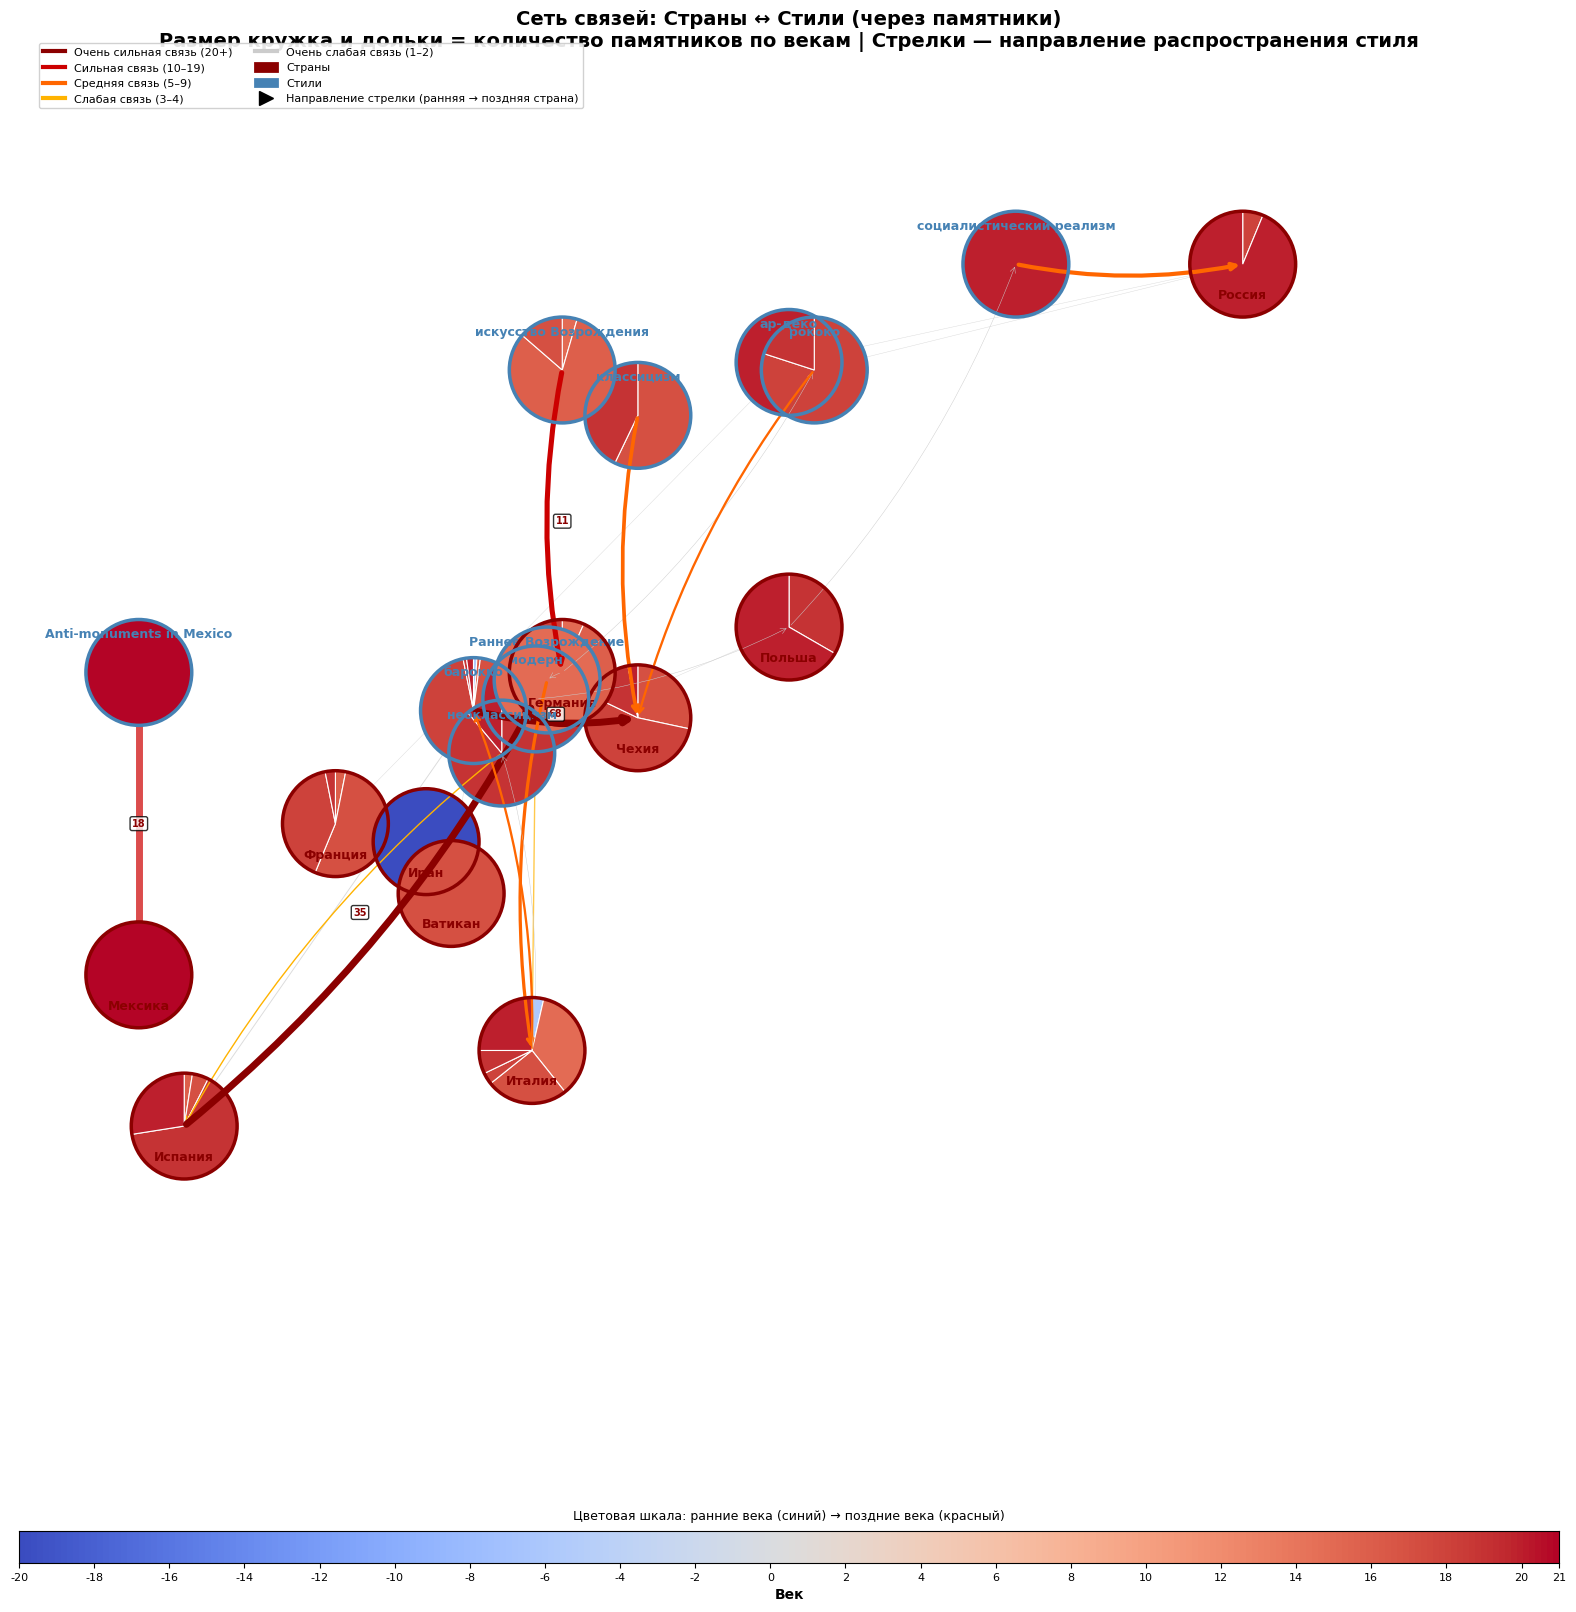


✅ Статическая визуализация сохранена как 'network_static_arrows_pie.png'

🔍 АНАЛИЗ СЕТИ: Ключевые узлы, направления и хронология

🎯 НАПРАВЛЕНИЯ РАСПРОСТРАНЕНИЯ СТИЛЕЙ:
   Anti-monuments in Mexico: только в Мексика (21 век)
   Раннее Возрождение: Германия → Италия
      • Германия: ~15 век
      • Италия: ~15 век
   ар-деко: только в Россия (20 век)
   барокко: Италия → Чехия
      • Италия: ~15 век
      • Испания: ~17 век
      • Ватикан: ~17 век
      • Германия: ~17 век
      • Франция: ~18 век
      • Чехия: ~18 век
   искусство Возрождения: Франция → Германия
      • Франция: ~16 век
      • Германия: ~16 век
   классицизм: Франция → Чехия
      • Франция: ~17 век
      • Испания: ~19 век
      • Чехия: ~19 век
   модерн: Испания → Польша
      • Испания: ~19 век
      • Италия: ~20 век
      • Польша: ~20 век
   неоклассицизм: Италия → Испания
      • Италия: ~19 век
      • Польша: ~19 век
      • Франция: ~19 век
      • Испания: ~19 век
   рококо: Германия → Чехия
      • Гер

In [6]:
# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("📊 Подготовка данных для сравнительного анализа...")
print(f"✅ Уникальных памятников: {len(df_unique)}")
print(f"✅ Уникальных стран: {df_unique['country'].nunique()}")
print(f"✅ Уникальных стилей: {df_unique['style'].nunique()}")

# ============================================================
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) со стрелками и кружками-дольками
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные с датами
print("\n📅 Загружаем данные с датами памятников...")
df_dates = pd.read_csv("data/monuments_country_style_date.csv")
print(f"✅ Загружено строк с датами: {len(df_dates)}")
print(f"📋 Колонки в файле: {list(df_dates.columns)}")

# Переименовываем колонки для совместимости
df_dates = df_dates.rename(columns={
    "monument": "URL",
    "monumentLabel": "monument",
    "countryLabel": "country",
    "styleLabel": "style",
    "inceptionYear": "date"  # ← вот правильное название колонки
})

# Извлекаем век из даты
def extract_century(date_str):
    """Извлекает век из строки даты. Ожидает год или диапазон."""
    if pd.isna(date_str):
        return None
    import re
    # Если это число (год)
    if isinstance(date_str, (int, float)):
        year = int(date_str)
    else:
        # Ищем все числа в строке
        numbers = re.findall(r'\d{3,4}', str(date_str))
        if not numbers:
            return None
        year = int(numbers[0])

    if year == 0:
        return None

    # Определяем век (1501 -> 16 век, 1500 -> 15 век)
    if year % 100 == 0:
        century = year // 100
    else:
        century = year // 100 + 1
    return century

df_dates['century'] = df_dates['date'].apply(extract_century)
df_dates = df_dates.dropna(subset=['century'])
df_dates['century'] = df_dates['century'].astype(int)

print(f"📊 Памятников с определённым веком: {len(df_dates)}")
print(f"📊 Диапазон веков: {df_dates['century'].min()} – {df_dates['century'].max()}")

# ============================================================
# Топ-10 стран и стилей
# ============================================================
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

print(f"\n🌍 Топ-10 стран: {top10_countries}")
print(f"🎨 Топ-10 стилей: {top10_styles}")

# ============================================================
# ГЕОГРАФИЧЕСКИЕ КООРДИНАТЫ СТРАН (нормализованные)
# ============================================================
country_coords_real = {
    'Россия':        (0.75, 0.82),
    'Германия':      (0.30, 0.55),
    'Франция':       (0.15, 0.45),
    'Италия':        (0.28, 0.30),
    'Испания':       (0.05, 0.25),
    'Чехия':         (0.35, 0.52),
    'Польша':        (0.45, 0.58),
    'Украина':       (0.55, 0.50),
    'Великобритания':(0.10, 0.60),
    'США':           (0.05, 0.75),
    'Мексика':       (0.02, 0.35),
    'Нидерланды':    (0.22, 0.55),
    'Австрия':       (0.32, 0.45),
    'Бельгия':       (0.18, 0.50),
    'Швейцария':     (0.22, 0.42),
    'Швеция':        (0.35, 0.75),
    'Норвегия':      (0.30, 0.78),
    'Дания':         (0.28, 0.65),
    'Финляндия':     (0.48, 0.80),
    'Греция':        (0.40, 0.22),
    'Турция':        (0.50, 0.18),
    'Япония':        (0.90, 0.50),
    'Китай':         (0.80, 0.45),
    'Индия':         (0.70, 0.30),
    'Бразилия':      (0.25, 0.10),
    'Аргентина':     (0.18, 0.05),
    'Канада':        (0.08, 0.80),
    'Австралия':     (0.85, 0.05),
    'Египет':        (0.45, 0.12),
    'Венгрия':       (0.40, 0.48),
}

def get_country_pos(country):
    if country in country_coords_real:
        return country_coords_real[country]
    seed = sum(ord(c) for c in country)
    np.random.seed(seed)
    return (np.random.uniform(0.1, 0.9), np.random.uniform(0.1, 0.9))

# ============================================================
# ПОЗИЦИИ СТИЛЕЙ — оптимизируем для минимизации пересечений
# ============================================================
def calculate_style_positions(countries, styles, df_filtered):
    style_positions = {}
    country_positions = {c: get_country_pos(c) for c in countries}

    for style in styles:
        linked_countries = df_filtered[df_filtered['style'] == style]['country'].unique()
        if len(linked_countries) > 0:
            xs = [country_positions[c][0] for c in linked_countries if c in country_positions]
            ys = [country_positions[c][1] for c in linked_countries if c in country_positions]
            if xs:
                cx = np.mean(xs)
                cy = np.mean(ys) + 0.12
                if len(xs) == 1:
                    cy += 0.08
                style_positions[style] = (cx, cy)
            else:
                style_positions[style] = (0.5, 0.85)
        else:
            style_positions[style] = (0.5, 0.85)

    return style_positions

network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

country_pos = {c: get_country_pos(c) for c in top10_countries}
style_pos = calculate_style_positions(top10_countries, top10_styles, network_data)
all_positions = {**country_pos, **style_pos}

print("\n📍 ПОЗИЦИИ СТРАН (географически осмысленные):")
for c in sorted(top10_countries):
    print(f"   {c}: {country_pos[c]}")

# ============================================================
# ОПРЕДЕЛЕНИЕ НАПРАВЛЕНИЯ СТРЕЛОК НА ОСНОВЕ ДАТ
# ============================================================
print("\n🔍 Определяем направления распространения стилей по датам...")

df_network_dates = df_dates[
    df_dates['country'].isin(top10_countries) &
    df_dates['style'].isin(top10_styles)
].copy()

style_country_century = df_network_dates.groupby(['style', 'country'])['century'].mean().reset_index()
style_country_century.columns = ['style', 'country', 'avg_century']

style_centuries = defaultdict(dict)
for _, row in style_country_century.iterrows():
    style_centuries[row['style']][row['country']] = row['avg_century']

style_directions = {}
for style, country_centuries in style_centuries.items():
    if len(country_centuries) >= 2:
        sorted_countries = sorted(country_centuries.items(), key=lambda x: x[1])
        style_directions[style] = {
            'earliest': sorted_countries[0][0],
            'latest': sorted_countries[-1][0],
            'centuries': country_centuries
        }
        print(f"   {style}: {sorted_countries[0][0]} ({sorted_countries[0][1]:.1f} в.) → {sorted_countries[-1][0]} ({sorted_countries[-1][1]:.1f} в.)")
    elif len(country_centuries) == 1:
        style_directions[style] = {
            'earliest': list(country_centuries.keys())[0],
            'latest': list(country_centuries.keys())[0],
            'centuries': country_centuries
        }

# ============================================================
# ПОДГОТОВКА ЦВЕТОВОЙ ШКАЛЫ ПО ВЕКАМ
# ============================================================
min_century = int(df_dates['century'].min())
max_century = int(df_dates['century'].max())
century_range = list(range(min_century, max_century + 1))

print(f"\n🎨 Цветовая шкала: {min_century}–{max_century} века")

import matplotlib.colors as mcolors
cmap = plt.cm.coolwarm

def century_to_color(century):
    if century is None or pd.isna(century):
        return 'lightgray'
    norm = (century - min_century) / max(1, (max_century - min_century))
    return mcolors.to_hex(cmap(norm))

# ============================================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ КРУЖКОВ-ДОЛЕК
# ============================================================
country_century_dist = {}
for country in top10_countries:
    country_data = df_dates[
        (df_dates['country'] == country) &
        (df_dates['style'].isin(top10_styles))
    ]
    century_counts = country_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        country_century_dist[country] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        country_century_dist[country] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

style_century_dist = {}
for style in top10_styles:
    style_data = df_dates[
        (df_dates['style'] == style) &
        (df_dates['country'].isin(top10_countries))
    ]
    century_counts = style_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        style_century_dist[style] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        style_century_dist[style] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

# ============================================================
# СОЗДАНИЕ СТАТИЧЕСКОЙ ВИЗУАЛИЗАЦИИ
# ============================================================
print("\n🎨 Рисуем статическую визуализацию...")

fig, ax = plt.subplots(1, 1, figsize=(22, 16))

# Рисуем РЁБРА
edge_data = []
for _, row in network_data.iterrows():
    country = row['country']
    style = row['style']
    if country in country_pos and style in style_pos:
        edge_data.append((country, style))

edge_weights = Counter(edge_data)

def get_edge_color(weight):
    if weight >= 20:
        return '#8B0000'
    elif weight >= 10:
        return '#CC0000'
    elif weight >= 5:
        return '#FF6600'
    elif weight >= 3:
        return '#FFB300'
    else:
        return '#CCCCCC'

drawn_edges = set()
for (country, style), weight in edge_weights.items():
    if (country, style) in drawn_edges or (style, country) in drawn_edges:
        continue
    drawn_edges.add((country, style))

    x1, y1 = country_pos[country]
    x2, y2 = style_pos[style]

    color = get_edge_color(weight)
    lw = min(weight / 3, 5)

    is_directed = False
    arrow_direction = None

    if style in style_directions:
        dir_info = style_directions[style]
        earliest = dir_info['earliest']
        latest = dir_info['latest']

        if earliest != latest:
            is_directed = True
            if country == earliest:
                arrow_direction = 'from_country_to_style'
            elif country == latest:
                arrow_direction = 'from_style_to_country'

    if is_directed and arrow_direction == 'from_country_to_style':
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.1'))
    elif is_directed and arrow_direction == 'from_style_to_country':
        ax.annotate('', xy=(x1, y1), xytext=(x2, y2),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.1'))
    else:
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=lw, alpha=0.7, zorder=1)

    if weight >= 10:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.annotate(str(weight), (mid_x, mid_y), fontsize=7, fontweight='bold',
                   color='darkred', ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# ============================================================
# КРУЖКИ-ДОЛЬКИ ДЛЯ СТРАН
# ============================================================
country_pie_radius = 0.035

for country in top10_countries:
    cx, cy = country_pos[country]
    dist = country_century_dist[country]

    if dist['total'] > 0:
        wedges, texts = ax.pie(
            dist['counts'],
            radius=country_pie_radius,
            center=(cx, cy),
            colors=[century_to_color(c) for c in dist['centuries']],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=0.8)
        )

    circle = plt.Circle((cx, cy), country_pie_radius, fill=False,
                        edgecolor='darkred', linewidth=2.5, zorder=5)
    ax.add_patch(circle)

    ax.annotate(country, (cx, cy),
                textcoords="offset points", xytext=(0, -25),
                ha='center', fontsize=9, fontweight='bold', color='darkred')

# ============================================================
# КРУЖКИ-ДОЛЬКИ ДЛЯ СТИЛЕЙ
# ============================================================
style_pie_radius = 0.035

for style in top10_styles:
    sx, sy = style_pos[style]
    dist = style_century_dist[style]

    if dist['total'] > 0:
        wedges, texts = ax.pie(
            dist['counts'],
            radius=style_pie_radius,
            center=(sx, sy),
            colors=[century_to_color(c) for c in dist['centuries']],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=0.8)
        )

    circle = plt.Circle((sx, sy), style_pie_radius, fill=False,
                        edgecolor='steelblue', linewidth=2.5, zorder=5)
    ax.add_patch(circle)

    ax.annotate(style, (sx, sy),
                textcoords="offset points", xytext=(0, 25),
                ha='center', fontsize=9, fontweight='bold', color='steelblue')

# ============================================================
# ЦВЕТОВАЯ ШКАЛА ВЕКОВ
# ============================================================
gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient = np.vstack((gradient, gradient))

ax_colorbar = fig.add_axes([0.15, 0.02, 0.7, 0.02])
ax_colorbar.imshow(gradient, aspect='auto', cmap=cmap, extent=[min_century, max_century, 0, 1])
ax_colorbar.set_yticks([])

centuries_major = list(range(min_century, max_century + 1))
ax_colorbar.set_xticks([c for c in centuries_major if c % 2 == 0 or c == min_century or c == max_century])
ax_colorbar.set_xticklabels([str(c) for c in centuries_major if c % 2 == 0 or c == min_century or c == max_century],
                             fontsize=8)
ax_colorbar.set_xlabel('Век', fontsize=10, fontweight='bold')
ax_colorbar.set_title('Цветовая шкала: ранние века (синий) → поздние века (красный)',
                      fontsize=9, pad=8)

# ============================================================
# ЛЕГЕНДА
# ============================================================
legend_elements = [
    Line2D([0], [0], color='#8B0000', lw=3, label='Очень сильная связь (20+)'),
    Line2D([0], [0], color='#CC0000', lw=3, label='Сильная связь (10–19)'),
    Line2D([0], [0], color='#FF6600', lw=3, label='Средняя связь (5–9)'),
    Line2D([0], [0], color='#FFB300', lw=3, label='Слабая связь (3–4)'),
    Line2D([0], [0], color='#CCCCCC', lw=3, label='Очень слабая связь (1–2)'),
    mpatches.Patch(facecolor='darkred', edgecolor='darkred', label='Страны', linewidth=2),
    mpatches.Patch(facecolor='steelblue', edgecolor='steelblue', label='Стили', linewidth=2),
    Line2D([0], [0], marker='>', color='black', lw=0, markerfacecolor='black',
           markersize=10, label='Направление стрелки (ранняя → поздняя страна)'),
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=8,
          framealpha=0.9, ncol=2, bbox_to_anchor=(0.0, 1.02))

# ============================================================
# ЗАГОЛОВОК И НАСТРОЙКИ
# ============================================================
ax.set_title(
    "Сеть связей: Страны ↔ Стили (через памятники)\n"
    "Размер кружка и дольки = количество памятников по векам | Стрелки — направление распространения стиля",
    fontsize=14, fontweight='bold', pad=15
)

ax.set_xlim(-0.05, 0.95)
ax.set_ylim(-0.05, 0.95)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig('network_static_arrows_pie.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Статическая визуализация сохранена как 'network_static_arrows_pie.png'")

# ============================================================
# ВЫВОД АНАЛИЗА
# ============================================================
print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Ключевые узлы, направления и хронология")
print("="*80)

print("\n🎯 НАПРАВЛЕНИЯ РАСПРОСТРАНЕНИЯ СТИЛЕЙ:")
for style, dir_info in style_directions.items():
    if dir_info['earliest'] != dir_info['latest']:
        print(f"   {style}: {dir_info['earliest']} → {dir_info['latest']}")
        for country, century in sorted(dir_info['centuries'].items(), key=lambda x: x[1]):
            print(f"      • {country}: ~{century:.0f} век")
    else:
        print(f"   {style}: только в {dir_info['earliest']} ({dir_info['centuries'][dir_info['earliest']]:.0f} век)")

print("\n📊 СТАТИСТИКА ПО СТИЛЯМ:")
for style in top10_styles:
    dist = style_century_dist[style]
    if dist['total'] > 0:
        min_c = min(dist['centuries'])
        max_c = max(dist['centuries'])
        print(f"   {style}: {dist['total']} памятников, {min_c}–{max_c} века")

print("\n📊 СТАТИСТИКА ПО СТРАНАМ:")
for country in top10_countries:
    dist = country_century_dist[country]
    if dist['total'] > 0:
        min_c = min(dist['centuries'])
        max_c = max(dist['centuries'])
        print(f"   {country}: {dist['total']} памятников, {min_c}–{max_c} века")

📊 Подготовка данных для сравнительного анализа...
✅ Уникальных памятников: 337
✅ Уникальных стран: 40
✅ Уникальных стилей: 77

📅 Загружаем данные с датами памятников...
✅ Загружено строк с датами: 567
📋 Колонки в файле: ['monument', 'monumentLabel', 'countryLabel', 'styleLabel', 'inceptionYear']
📊 Памятников с определённым веком: 464
📊 Диапазон веков: -20 – 21

🌍 Топ-10 стран: ['Чехия', 'Испания', 'Италия', 'Германия', 'Мексика', 'Франция', 'Иран', 'Россия', 'Польша', 'Ватикан']
🎨 Топ-10 стилей: ['барокко', 'модерн', 'Anti-monuments in Mexico', 'социалистический реализм', 'классицизм', 'искусство Возрождения', 'ар-деко', 'неоклассицизм', 'Раннее Возрождение', 'рококо']

📍 ПОЗИЦИИ СТРАН:
   Ватикан: (0.2265271607094589, 0.40383265853583405)
   Германия: (0.35, 0.65)
   Иран: (0.20997559101485433, 0.43809765898470177)
   Испания: (0.03, 0.2)
   Италия: (0.3, 0.25)
   Мексика: (0.02, 0.08)
   Польша: (0.52, 0.68)
   Россия: (0.85, 0.85)
   Франция: (0.12, 0.5)
   Чехия: (0.4, 0.58)

📍 ПОЗ

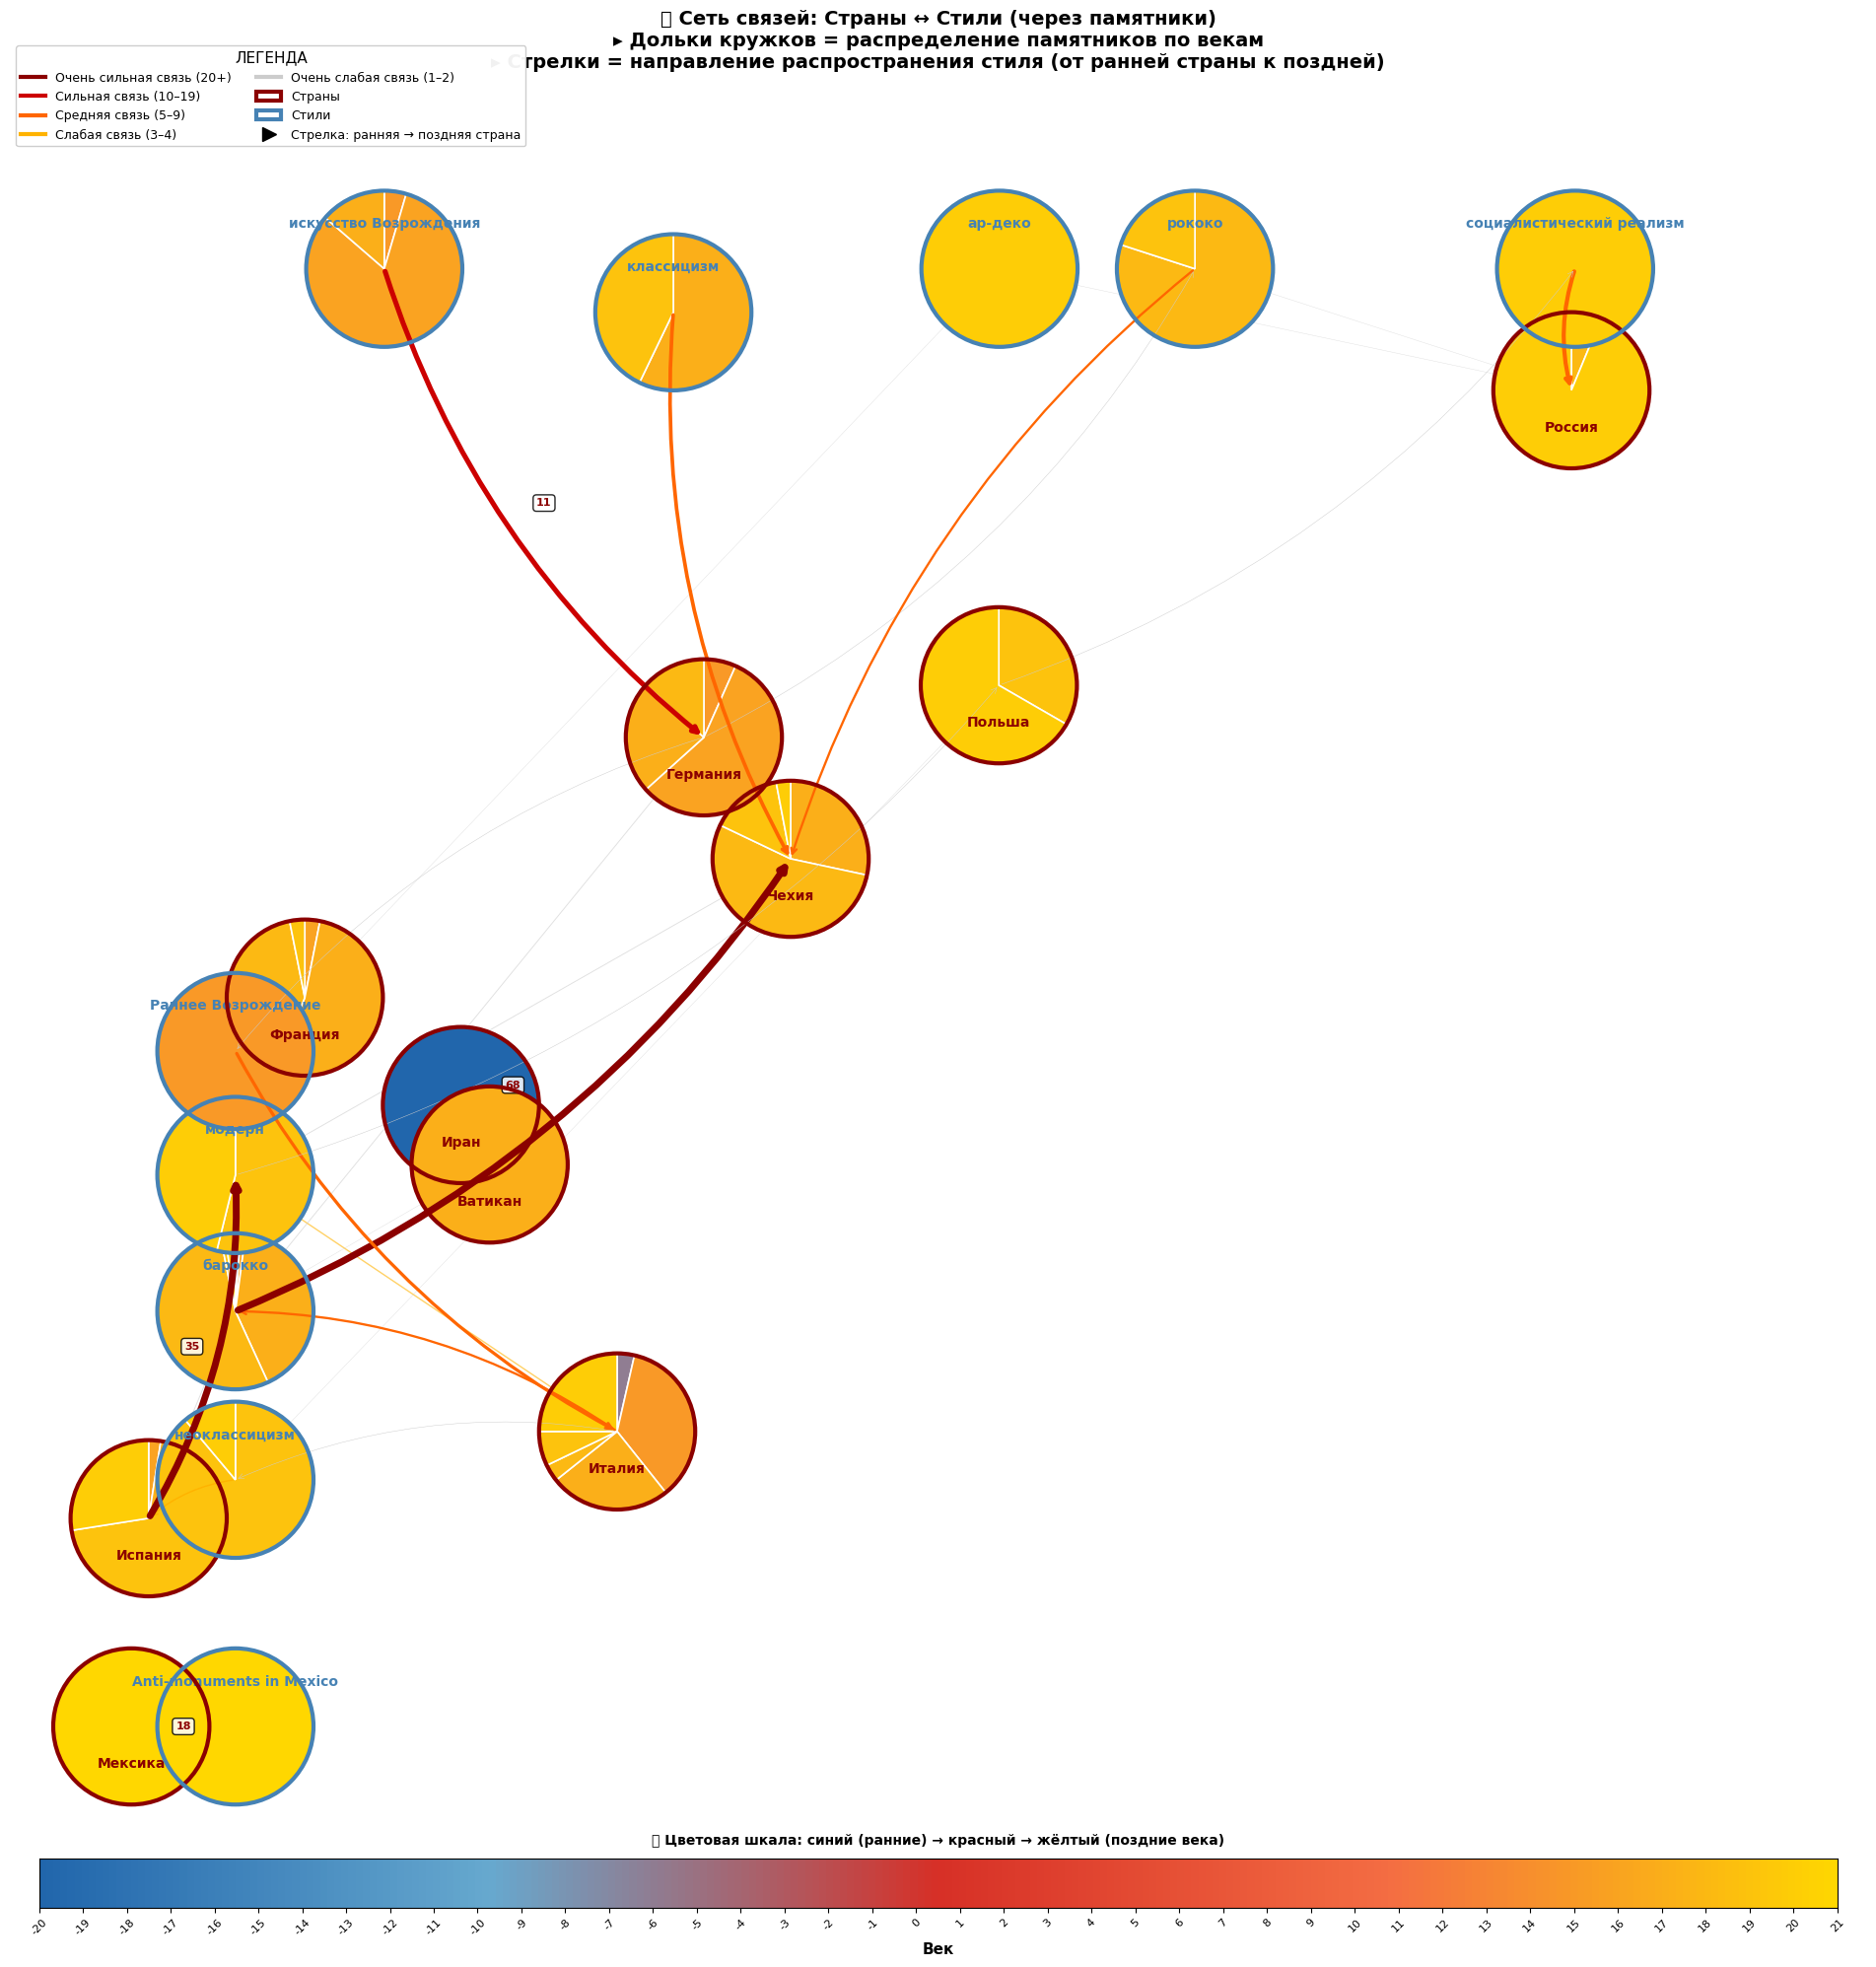


✅ Статическая визуализация сохранена как 'network_static_arrows_pie.png'

🔍 АНАЛИЗ СЕТИ: Ключевые узлы, направления и хронология

🎯 НАПРАВЛЕНИЯ РАСПРОСТРАНЕНИЯ СТИЛЕЙ:
   Anti-monuments in Mexico: только в Мексика (21 век)
   Раннее Возрождение: Германия → Италия
      • Германия: ~15 век
      • Италия: ~15 век
   ар-деко: только в Россия (20 век)
   барокко: Италия → Чехия
      • Италия: ~15 век
      • Испания: ~17 век
      • Ватикан: ~17 век
      • Германия: ~17 век
      • Франция: ~18 век
      • Чехия: ~18 век
   искусство Возрождения: Франция → Германия
      • Франция: ~16 век
      • Германия: ~16 век
   классицизм: Франция → Чехия
      • Франция: ~17 век
      • Испания: ~19 век
      • Чехия: ~19 век
   модерн: Испания → Польша
      • Испания: ~19 век
      • Италия: ~20 век
      • Польша: ~20 век
   неоклассицизм: Италия → Испания
      • Италия: ~19 век
      • Польша: ~19 век
      • Франция: ~19 век
      • Испания: ~19 век
   рококо: Германия → Чехия
      • Гер

In [7]:
# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("📊 Подготовка данных для сравнительного анализа...")
print(f"✅ Уникальных памятников: {len(df_unique)}")
print(f"✅ Уникальных стран: {df_unique['country'].nunique()}")
print(f"✅ Уникальных стилей: {df_unique['style'].nunique()}")

# ============================================================
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) со стрелками и кружками-дольками
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные с датами
print("\n📅 Загружаем данные с датами памятников...")
df_dates = pd.read_csv("data/monuments_country_style_date.csv")
print(f"✅ Загружено строк с датами: {len(df_dates)}")
print(f"📋 Колонки в файле: {list(df_dates.columns)}")

# Переименовываем колонки для совместимости
df_dates = df_dates.rename(columns={
    "monument": "URL",
    "monumentLabel": "monument",
    "countryLabel": "country",
    "styleLabel": "style",
    "inceptionYear": "date"
})

# Извлекаем век из даты
def extract_century(date_str):
    """Извлекает век из строки даты. Ожидает год или диапазон."""
    if pd.isna(date_str):
        return None
    import re
    if isinstance(date_str, (int, float)):
        year = int(date_str)
    else:
        numbers = re.findall(r'\d{3,4}', str(date_str))
        if not numbers:
            return None
        year = int(numbers[0])

    if year == 0:
        return None

    if year % 100 == 0:
        century = year // 100
    else:
        century = year // 100 + 1
    return century

df_dates['century'] = df_dates['date'].apply(extract_century)
df_dates = df_dates.dropna(subset=['century'])
df_dates['century'] = df_dates['century'].astype(int)

print(f"📊 Памятников с определённым веком: {len(df_dates)}")
print(f"📊 Диапазон веков: {df_dates['century'].min()} – {df_dates['century'].max()}")

# ============================================================
# Топ-10 стран и стилей
# ============================================================
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

print(f"\n🌍 Топ-10 стран: {top10_countries}")
print(f"🎨 Топ-10 стилей: {top10_styles}")

# ============================================================
# ГЕОГРАФИЧЕСКИЕ КООРДИНАТЫ СТРАН — БОЛЕЕ РАЗРЕЖЕННЫЕ
# ============================================================
# Увеличиваем разброс: страны дальше друг от друга
country_coords_real = {
    'Россия':        (0.85, 0.85),
    'Германия':      (0.35, 0.65),
    'Франция':       (0.12, 0.50),
    'Италия':        (0.30, 0.25),
    'Испания':       (0.03, 0.20),
    'Чехия':         (0.40, 0.58),
    'Польша':        (0.52, 0.68),
    'Украина':       (0.65, 0.55),
    'Великобритания':(0.08, 0.72),
    'США':           (0.05, 0.90),
    'Мексика':       (0.02, 0.08),
    'Нидерланды':    (0.20, 0.62),
    'Австрия':       (0.34, 0.42),
    'Бельгия':       (0.16, 0.55),
    'Швейцария':     (0.22, 0.38),
    'Швеция':        (0.42, 0.88),
    'Норвегия':      (0.32, 0.92),
    'Дания':         (0.30, 0.76),
    'Финляндия':     (0.58, 0.92),
    'Греция':        (0.48, 0.12),
    'Турция':        (0.60, 0.08),
    'Япония':        (0.95, 0.55),
    'Китай':         (0.88, 0.42),
    'Индия':         (0.78, 0.22),
    'Бразилия':      (0.22, 0.05),
    'Аргентина':     (0.15, 0.03),
    'Канада':        (0.08, 0.95),
    'Австралия':     (0.92, 0.05),
    'Египет':        (0.55, 0.05),
    'Венгрия':       (0.46, 0.50),
}

def get_country_pos(country):
    if country in country_coords_real:
        return country_coords_real[country]
    seed = sum(ord(c) for c in country)
    np.random.seed(seed)
    return (np.random.uniform(0.1, 0.9), np.random.uniform(0.1, 0.9))

# ============================================================
# ПОЗИЦИИ СТИЛЕЙ — ОТОДВИГАЕМ ДАЛЬШЕ ОТ СТРАН
# ============================================================
def calculate_style_positions(countries, styles, df_filtered):
    style_positions = {}
    country_positions = {c: get_country_pos(c) for c in countries}

    # Занятые позиции для избежания наложений
    occupied = set()

    for i, style in enumerate(styles):
        linked_countries = df_filtered[df_filtered['style'] == style]['country'].unique()
        if len(linked_countries) > 0:
            xs = [country_positions[c][0] for c in linked_countries if c in country_positions]
            ys = [country_positions[c][1] for c in linked_countries if c in country_positions]
            if xs:
                cx = np.mean(xs)
                cy = np.mean(ys)

                # Отодвигаем стиль значительно дальше от стран
                # Определяем направление от центра масс
                center_x, center_y = 0.45, 0.45
                dx = cx - center_x
                dy = cy - center_y
                dist = np.sqrt(dx**2 + dy**2)

                if dist > 0:
                    # Толкаем дальше от центра на 0.25-0.35 единиц
                    push = 0.30
                    cx_new = cx + (dx / dist) * push
                    cy_new = cy + (dy / dist) * push
                else:
                    cx_new = cx
                    cy_new = cy + 0.30

                # Добавляем небольшой случайный сдвиг чтобы стили не накладывались
                np.random.seed(sum(ord(c) for c in style))
                cx_new += np.random.uniform(-0.06, 0.06)
                cy_new += np.random.uniform(-0.06, 0.06)

                # Ограничиваем в пределах холста
                cx_new = np.clip(cx_new, 0.08, 0.92)
                cy_new = np.clip(cy_new, 0.08, 0.92)

                style_positions[style] = (cx_new, cy_new)
            else:
                style_positions[style] = (0.5, 0.90)
        else:
            style_positions[style] = (0.5, 0.90)

    return style_positions

network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

country_pos = {c: get_country_pos(c) for c in top10_countries}
style_pos = calculate_style_positions(top10_countries, top10_styles, network_data)
all_positions = {**country_pos, **style_pos}

print("\n📍 ПОЗИЦИИ СТРАН:")
for c in sorted(top10_countries):
    print(f"   {c}: {country_pos[c]}")
print("\n📍 ПОЗИЦИИ СТИЛЕЙ:")
for s in sorted(top10_styles):
    print(f"   {s}: {style_pos[s]}")

# ============================================================
# ОПРЕДЕЛЕНИЕ НАПРАВЛЕНИЯ СТРЕЛОК НА ОСНОВЕ ДАТ
# ============================================================
print("\n🔍 Определяем направления распространения стилей по датам...")

df_network_dates = df_dates[
    df_dates['country'].isin(top10_countries) &
    df_dates['style'].isin(top10_styles)
].copy()

style_country_century = df_network_dates.groupby(['style', 'country'])['century'].mean().reset_index()
style_country_century.columns = ['style', 'country', 'avg_century']

style_centuries = defaultdict(dict)
for _, row in style_country_century.iterrows():
    style_centuries[row['style']][row['country']] = row['avg_century']

style_directions = {}
for style, country_centuries in style_centuries.items():
    if len(country_centuries) >= 2:
        sorted_countries = sorted(country_centuries.items(), key=lambda x: x[1])
        style_directions[style] = {
            'earliest': sorted_countries[0][0],
            'latest': sorted_countries[-1][0],
            'centuries': country_centuries
        }
        print(f"   {style}: {sorted_countries[0][0]} ({sorted_countries[0][1]:.1f} в.) → {sorted_countries[-1][0]} ({sorted_countries[-1][1]:.1f} в.)")
    elif len(country_centuries) == 1:
        style_directions[style] = {
            'earliest': list(country_centuries.keys())[0],
            'latest': list(country_centuries.keys())[0],
            'centuries': country_centuries
        }

# ============================================================
# ПОДГОТОВКА ЦВЕТОВОЙ ШКАЛЫ: СИНИЙ → КРАСНЫЙ → ЖЁЛТЫЙ
# ============================================================
min_century = int(df_dates['century'].min())
max_century = int(df_dates['century'].max())
century_range = list(range(min_century, max_century + 1))

print(f"\n🎨 Цветовая шкала: {min_century}–{max_century} века")

import matplotlib.colors as mcolors

# Создаём свой градиент: синий → красный → жёлтый
from matplotlib.colors import LinearSegmentedColormap

# Определяем кастомную цветовую карту
colors_list = [
    (0.0, '#2166AC'),    # тёмно-синий (ранние века)
    (0.25, '#67A9CF'),   # светло-синий
    (0.5, '#D73027'),    # красный (средние века)
    (0.75, '#F46D43'),   # оранжево-красный
    (1.0, '#FFD700'),    # золотой/жёлтый (поздние века)
]

cmap = LinearSegmentedColormap.from_list('custom_century', colors_list, N=256)

def century_to_color(century):
    """Преобразует век в цвет по шкале синий→красный→жёлтый."""
    if century is None or pd.isna(century):
        return 'lightgray'
    norm = (century - min_century) / max(1, (max_century - min_century))
    return mcolors.to_hex(cmap(norm))

# ============================================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ КРУЖКОВ-ДОЛЕК
# ============================================================
country_century_dist = {}
for country in top10_countries:
    country_data = df_dates[
        (df_dates['country'] == country) &
        (df_dates['style'].isin(top10_styles))
    ]
    century_counts = country_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        country_century_dist[country] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        country_century_dist[country] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

style_century_dist = {}
for style in top10_styles:
    style_data = df_dates[
        (df_dates['style'] == style) &
        (df_dates['country'].isin(top10_countries))
    ]
    century_counts = style_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        style_century_dist[style] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        style_century_dist[style] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

# ============================================================
# СОЗДАНИЕ СТАТИЧЕСКОЙ ВИЗУАЛИЗАЦИИ
# ============================================================
print("\n🎨 Рисуем статическую визуализацию...")

fig, ax = plt.subplots(1, 1, figsize=(24, 20))

# Рисуем РЁБРА
edge_data = []
for _, row in network_data.iterrows():
    country = row['country']
    style = row['style']
    if country in country_pos and style in style_pos:
        edge_data.append((country, style))

edge_weights = Counter(edge_data)

def get_edge_color(weight):
    if weight >= 20:
        return '#8B0000'
    elif weight >= 10:
        return '#CC0000'
    elif weight >= 5:
        return '#FF6600'
    elif weight >= 3:
        return '#FFB300'
    else:
        return '#CCCCCC'

drawn_edges = set()
for (country, style), weight in edge_weights.items():
    if (country, style) in drawn_edges or (style, country) in drawn_edges:
        continue
    drawn_edges.add((country, style))

    x1, y1 = country_pos[country]
    x2, y2 = style_pos[style]

    color = get_edge_color(weight)
    lw = min(weight / 3, 5)

    is_directed = False
    arrow_direction = None

    if style in style_directions:
        dir_info = style_directions[style]
        earliest = dir_info['earliest']
        latest = dir_info['latest']

        if earliest != latest:
            is_directed = True
            if country == earliest:
                arrow_direction = 'from_country_to_style'
            elif country == latest:
                arrow_direction = 'from_style_to_country'

    if is_directed and arrow_direction == 'from_country_to_style':
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.15'))
    elif is_directed and arrow_direction == 'from_style_to_country':
        ax.annotate('', xy=(x1, y1), xytext=(x2, y2),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.15'))
    else:
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=lw, alpha=0.6, zorder=1)

    if weight >= 10:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.annotate(str(weight), (mid_x, mid_y), fontsize=8, fontweight='bold',
                   color='darkred', ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

# ============================================================
# КРУЖКИ-ДОЛЬКИ ДЛЯ СТРАН — УВЕЛИЧЕННЫЙ РАЗМЕР
# ============================================================
country_pie_radius = 0.045  # увеличено с 0.035

for country in top10_countries:
    cx, cy = country_pos[country]
    dist = country_century_dist[country]

    if dist['total'] > 0:
        wedges, texts = ax.pie(
            dist['counts'],
            radius=country_pie_radius,
            center=(cx, cy),
            colors=[century_to_color(c) for c in dist['centuries']],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=1.2)
        )

    circle = plt.Circle((cx, cy), country_pie_radius, fill=False,
                        edgecolor='darkred', linewidth=3, zorder=5)
    ax.add_patch(circle)

    ax.annotate(country, (cx, cy),
                textcoords="offset points", xytext=(0, -30),
                ha='center', fontsize=10, fontweight='bold', color='darkred')

# ============================================================
# КРУЖКИ-ДОЛЬКИ ДЛЯ СТИЛЕЙ — УВЕЛИЧЕННЫЙ РАЗМЕР
# ============================================================
style_pie_radius = 0.045  # увеличено с 0.035

for style in top10_styles:
    sx, sy = style_pos[style]
    dist = style_century_dist[style]

    if dist['total'] > 0:
        wedges, texts = ax.pie(
            dist['counts'],
            radius=style_pie_radius,
            center=(sx, sy),
            colors=[century_to_color(c) for c in dist['centuries']],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=1.2)
        )

    circle = plt.Circle((sx, sy), style_pie_radius, fill=False,
                        edgecolor='steelblue', linewidth=3, zorder=5)
    ax.add_patch(circle)

    ax.annotate(style, (sx, sy),
                textcoords="offset points", xytext=(0, 30),
                ha='center', fontsize=10, fontweight='bold', color='steelblue')

# ============================================================
# ЦВЕТОВАЯ ШКАЛА ВЕКОВ — СИНИЙ → КРАСНЫЙ → ЖЁЛТЫЙ
# ============================================================
gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient = np.vstack((gradient, gradient))

ax_colorbar = fig.add_axes([0.12, 0.03, 0.76, 0.025])
ax_colorbar.imshow(gradient, aspect='auto', cmap=cmap, extent=[min_century, max_century, 0, 1])
ax_colorbar.set_yticks([])

# Подписи каждого века
all_centuries = list(range(min_century, max_century + 1))
ax_colorbar.set_xticks(all_centuries)
ax_colorbar.set_xticklabels([str(c) for c in all_centuries], fontsize=8, rotation=45)
ax_colorbar.set_xlabel('Век', fontsize=11, fontweight='bold')
ax_colorbar.set_title('🕐 Цветовая шкала: синий (ранние) → красный → жёлтый (поздние века)',
                      fontsize=10, pad=10, fontweight='bold')

# ============================================================
# ЛЕГЕНДА — РАСШИРЕННАЯ
# ============================================================
legend_elements = [
    Line2D([0], [0], color='#8B0000', lw=3, label='Очень сильная связь (20+)'),
    Line2D([0], [0], color='#CC0000', lw=3, label='Сильная связь (10–19)'),
    Line2D([0], [0], color='#FF6600', lw=3, label='Средняя связь (5–9)'),
    Line2D([0], [0], color='#FFB300', lw=3, label='Слабая связь (3–4)'),
    Line2D([0], [0], color='#CCCCCC', lw=3, label='Очень слабая связь (1–2)'),
    mpatches.Patch(facecolor='white', edgecolor='darkred', linewidth=3, label='Страны'),
    mpatches.Patch(facecolor='white', edgecolor='steelblue', linewidth=3, label='Стили'),
    Line2D([0], [0], marker='>', color='black', lw=0, markerfacecolor='black',
           markersize=10, label='Стрелка: ранняя → поздняя страна'),
]

leg = ax.legend(handles=legend_elements, loc='upper left', fontsize=9,
          framealpha=0.95, ncol=2, bbox_to_anchor=(0.0, 1.03),
          title='ЛЕГЕНДА',
          title_fontsize=11)

# ============================================================
# ЗАГОЛОВОК
# ============================================================
ax.set_title(
    "🌐 Сеть связей: Страны ↔ Стили (через памятники)\n"
    "▸ Дольки кружков = распределение памятников по векам\n"
    "▸ Стрелки = направление распространения стиля (от ранней страны к поздней)",
    fontsize=14, fontweight='bold', pad=20
)

ax.set_xlim(-0.05, 1.02)
ax.set_ylim(-0.05, 1.02)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig('network_static_arrows_pie.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Статическая визуализация сохранена как 'network_static_arrows_pie.png'")

# ============================================================
# ВЫВОД АНАЛИЗА
# ============================================================
print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Ключевые узлы, направления и хронология")
print("="*80)

print("\n🎯 НАПРАВЛЕНИЯ РАСПРОСТРАНЕНИЯ СТИЛЕЙ:")
for style, dir_info in style_directions.items():
    if dir_info['earliest'] != dir_info['latest']:
        print(f"   {style}: {dir_info['earliest']} → {dir_info['latest']}")
        for country, century in sorted(dir_info['centuries'].items(), key=lambda x: x[1]):
            print(f"      • {country}: ~{century:.0f} век")
    else:
        print(f"   {style}: только в {dir_info['earliest']} ({dir_info['centuries'][dir_info['earliest']]:.0f} век)")

print("\n📊 СТАТИСТИКА ПО СТИЛЯМ:")
for style in top10_styles:
    dist = style_century_dist[style]
    if dist['total'] > 0:
        min_c = min(dist['centuries'])
        max_c = max(dist['centuries'])
        print(f"   {style}: {dist['total']} памятников, {min_c}–{max_c} века")

print("\n📊 СТАТИСТИКА ПО СТРАНАМ:")
for country in top10_countries:
    dist = country_century_dist[country]
    if dist['total'] > 0:
        min_c = min(dist['centuries'])
        max_c = max(dist['centuries'])
        print(f"   {country}: {dist['total']} памятников, {min_c}–{max_c} века")

📊 Подготовка данных для сравнительного анализа...
✅ Уникальных памятников: 337
✅ Уникальных стран: 40
✅ Уникальных стилей: 77

📅 Загружаем данные с датами памятников...
✅ Загружено строк с датами: 567
📋 Колонки в файле: ['monument', 'monumentLabel', 'countryLabel', 'styleLabel', 'inceptionYear']
📊 Памятников с определённым веком: 464
📊 Диапазон веков: -20 – 21

🌍 Топ-10 стран: ['Чехия', 'Испания', 'Италия', 'Германия', 'Мексика', 'Франция', 'Иран', 'Россия', 'Польша', 'Ватикан']
🎨 Топ-10 стилей: ['барокко', 'модерн', 'Anti-monuments in Mexico', 'социалистический реализм', 'классицизм', 'искусство Возрождения', 'ар-деко', 'неоклассицизм', 'Раннее Возрождение', 'рококо']

📏 Проверка расстояний между узлами:
   Минимальное расстояние: 0.000
   ⚠️ Близкие пары (d<0.05):
      Испания — модерн: d=0.032
      Испания — неоклассицизм: d=0.036
      Испания — Раннее Возрождение: d=0.041
      Мексика — модерн: d=0.039
      Мексика — неоклассицизм: d=0.030

📍 ПОЗИЦИИ СТРАН:
   Ватикан: (0.2265

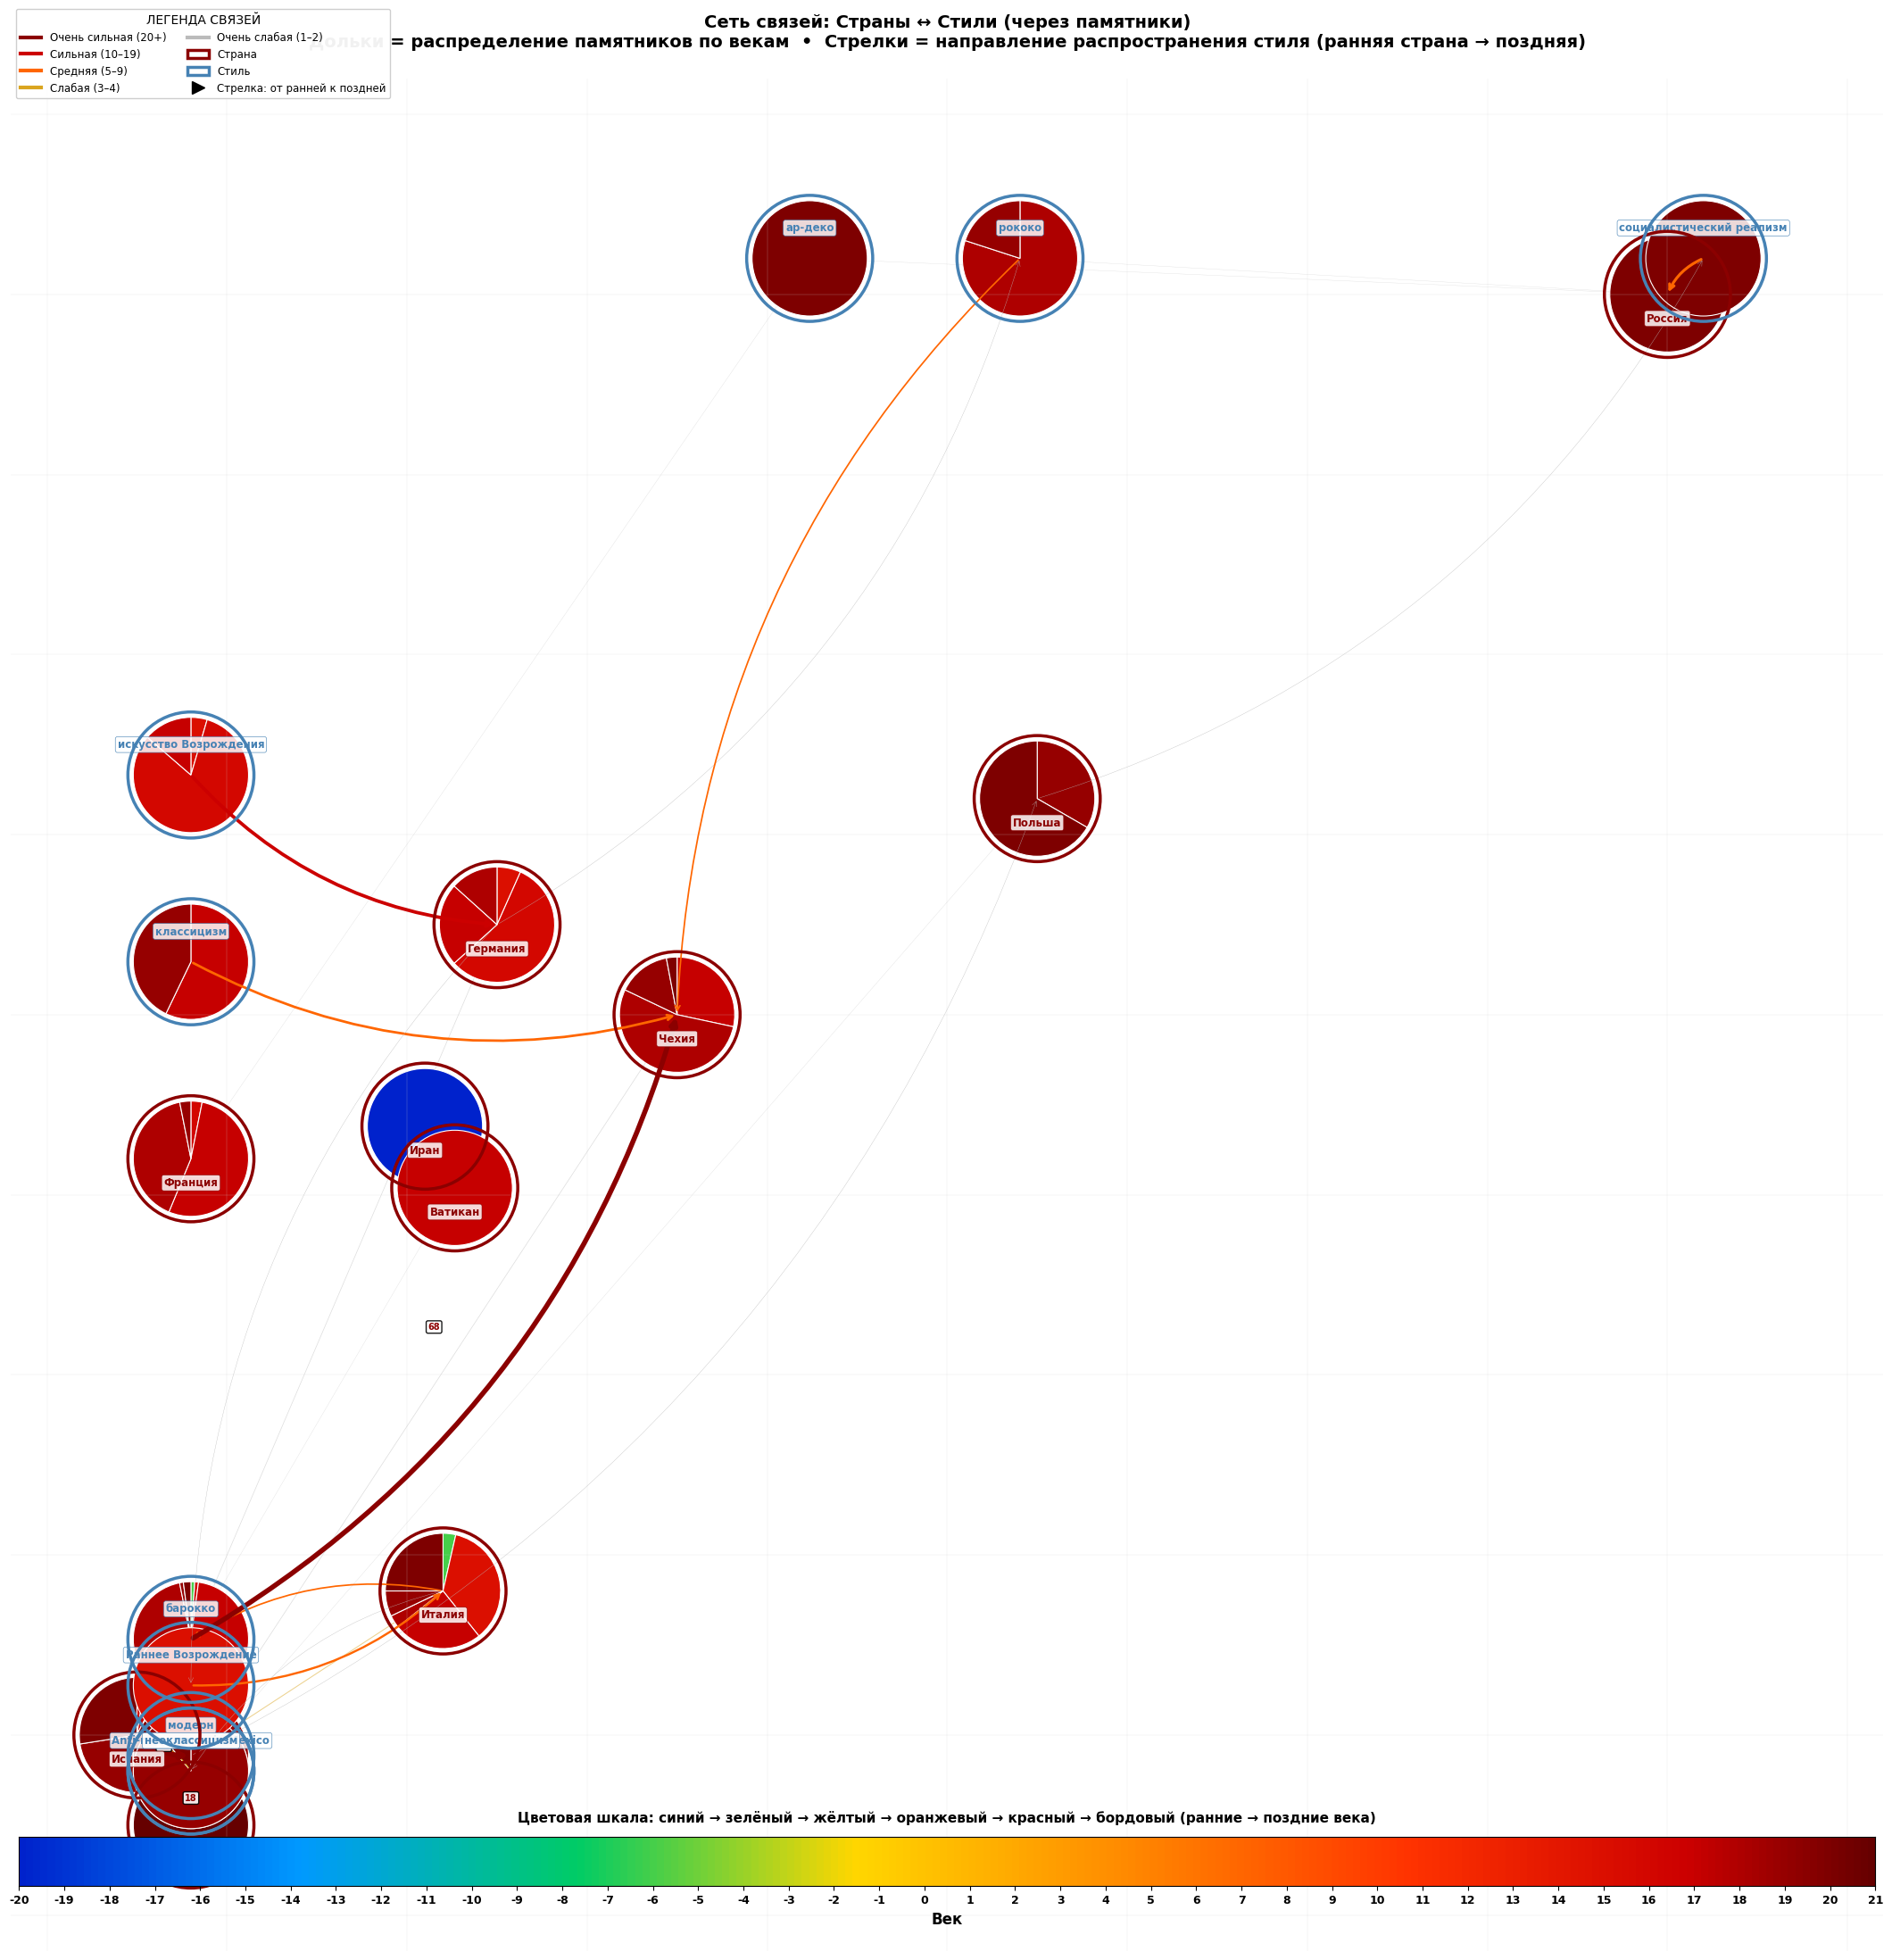


✅ Статическая визуализация сохранена как 'network_static_arrows_pie.png'

🔍 АНАЛИЗ СЕТИ: Ключевые узлы, направления и хронология

🎯 НАПРАВЛЕНИЯ РАСПРОСТРАНЕНИЯ СТИЛЕЙ:
   Anti-monuments in Mexico: только в Мексика (21 век)
   Раннее Возрождение: Германия → Италия
      • Германия: ~15 век
      • Италия: ~15 век
   ар-деко: только в Россия (20 век)
   барокко: Италия → Чехия
      • Италия: ~15 век
      • Испания: ~17 век
      • Ватикан: ~17 век
      • Германия: ~17 век
      • Франция: ~18 век
      • Чехия: ~18 век
   искусство Возрождения: Франция → Германия
      • Франция: ~16 век
      • Германия: ~16 век
   классицизм: Франция → Чехия
      • Франция: ~17 век
      • Испания: ~19 век
      • Чехия: ~19 век
   модерн: Испания → Польша
      • Испания: ~19 век
      • Италия: ~20 век
      • Польша: ~20 век
   неоклассицизм: Италия → Испания
      • Италия: ~19 век
      • Польша: ~19 век
      • Франция: ~19 век
      • Испания: ~19 век
   рококо: Германия → Чехия
      • Гер

In [8]:
# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("📊 Подготовка данных для сравнительного анализа...")
print(f"✅ Уникальных памятников: {len(df_unique)}")
print(f"✅ Уникальных стран: {df_unique['country'].nunique()}")
print(f"✅ Уникальных стилей: {df_unique['style'].nunique()}")

# ============================================================
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) со стрелками и кружками-дольками
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные с датами
print("\n📅 Загружаем данные с датами памятников...")
df_dates = pd.read_csv("data/monuments_country_style_date.csv")
print(f"✅ Загружено строк с датами: {len(df_dates)}")
print(f"📋 Колонки в файле: {list(df_dates.columns)}")

# Переименовываем колонки для совместимости
df_dates = df_dates.rename(columns={
    "monument": "URL",
    "monumentLabel": "monument",
    "countryLabel": "country",
    "styleLabel": "style",
    "inceptionYear": "date"
})

# Извлекаем век из даты
def extract_century(date_str):
    """Извлекает век из строки даты. Ожидает год или диапазон."""
    if pd.isna(date_str):
        return None
    import re
    if isinstance(date_str, (int, float)):
        year = int(date_str)
    else:
        numbers = re.findall(r'\d{3,4}', str(date_str))
        if not numbers:
            return None
        year = int(numbers[0])

    if year == 0:
        return None

    if year % 100 == 0:
        century = year // 100
    else:
        century = year // 100 + 1
    return century

df_dates['century'] = df_dates['date'].apply(extract_century)
df_dates = df_dates.dropna(subset=['century'])
df_dates['century'] = df_dates['century'].astype(int)

print(f"📊 Памятников с определённым веком: {len(df_dates)}")
print(f"📊 Диапазон веков: {df_dates['century'].min()} – {df_dates['century'].max()}")

# ============================================================
# Топ-10 стран и стилей
# ============================================================
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

print(f"\n🌍 Топ-10 стран: {top10_countries}")
print(f"🎨 Топ-10 стилей: {top10_styles}")

# ============================================================
# ГЕОГРАФИЧЕСКИЕ КООРДИНАТЫ СТРАН — МАКСИМАЛЬНЫЙ РАЗБРОС
# ============================================================
# Разносим по всему холсту [0.05, 0.95] x [0.05, 0.95]
country_coords_real = {
    'Россия':        (0.90, 0.90),
    'Германия':      (0.25, 0.55),
    'Франция':       (0.08, 0.42),
    'Италия':        (0.22, 0.18),
    'Испания':       (0.05, 0.10),
    'Чехия':         (0.35, 0.50),
    'Польша':        (0.55, 0.62),
    'Украина':       (0.75, 0.48),
    'Великобритания':(0.06, 0.68),
    'США':           (0.10, 0.90),
    'Мексика':       (0.08, 0.05),
    'Нидерланды':    (0.15, 0.55),
    'Австрия':       (0.30, 0.35),
    'Бельгия':       (0.12, 0.50),
    'Швейцария':     (0.18, 0.30),
    'Швеция':        (0.40, 0.90),
    'Норвегия':      (0.28, 0.93),
    'Дания':         (0.22, 0.78),
    'Финляндия':     (0.62, 0.93),
    'Греция':        (0.55, 0.08),
    'Турция':        (0.70, 0.05),
    'Япония':        (0.95, 0.45),
    'Китай':         (0.85, 0.35),
    'Индия':         (0.75, 0.15),
    'Бразилия':      (0.25, 0.05),
    'Аргентина':     (0.18, 0.03),
    'Канада':        (0.05, 0.95),
    'Австралия':     (0.92, 0.05),
    'Египет':        (0.60, 0.05),
    'Венгрия':       (0.48, 0.42),
}

def get_country_pos(country):
    if country in country_coords_real:
        return country_coords_real[country]
    seed = sum(ord(c) for c in country)
    np.random.seed(seed)
    return (np.random.uniform(0.1, 0.9), np.random.uniform(0.1, 0.9))

# ============================================================
# ПОЗИЦИИ СТИЛЕЙ — СИЛЬНО ОТОДВИГАЕМ ОТ СТРАН
# ============================================================
def calculate_style_positions(countries, styles, df_filtered):
    style_positions = {}
    country_positions = {c: get_country_pos(c) for c in countries}

    # Сначала собираем стили по числу связанных стран
    style_connections = {}
    for style in styles:
        linked = df_filtered[df_filtered['style'] == style]['country'].unique()
        style_connections[style] = [c for c in linked if c in country_positions]

    # Находим центр холста
    center_x, center_y = 0.50, 0.50

    for i, (style, linked_countries) in enumerate(style_connections.items()):
        if len(linked_countries) > 0:
            xs = [country_positions[c][0] for c in linked_countries]
            ys = [country_positions[c][1] for c in linked_countries]

            # Центр масс связанных стран
            cx = np.mean(xs)
            cy = np.mean(ys)

            # Сдвигаем стиль ДАЛЕКО от центра масс стран к краю холста
            # Определяем направление от центра холста к центру масс стран
            dx = cx - center_x
            dy = cy - center_y

            # Нормализуем направление
            dist = np.sqrt(dx**2 + dy**2)
            if dist < 0.01:
                dx, dy = 0, 1
                dist = 1

            # Толкаем стиль к противоположному краю холста
            # От центра масс стран двигаемся дальше от центра холста
            push_distance = 0.35 + np.random.uniform(0.05, 0.15)  # сильный сдвиг

            cx_new = cx + (dx / dist) * push_distance
            cy_new = cy + (dy / dist) * push_distance

            # Добавляем смещение чтобы стили не накладывались друг на друга
            angle = (i / len(styles)) * 2 * np.pi
            cx_new += np.cos(angle) * 0.05
            cy_new += np.sin(angle) * 0.05

            # Жёстко ограничиваем края холста
            cx_new = np.clip(cx_new, 0.08, 0.92)
            cy_new = np.clip(cy_new, 0.08, 0.92)

            style_positions[style] = (cx_new, cy_new)
        else:
            style_positions[style] = (0.5, 0.90)

    return style_positions

network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

country_pos = {c: get_country_pos(c) for c in top10_countries}
style_pos = calculate_style_positions(top10_countries, top10_styles, network_data)
all_positions = {**country_pos, **style_pos}

# Проверяем минимальные расстояния между узлами
print("\n📏 Проверка расстояний между узлами:")
all_nodes = {**country_pos, **style_pos}
min_dist = float('inf')
close_pairs = []
for n1, p1 in all_nodes.items():
    for n2, p2 in all_nodes.items():
        if n1 < n2:
            d = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
            if d < min_dist:
                min_dist = d
            if d < 0.05:
                close_pairs.append((n1, n2, d))
print(f"   Минимальное расстояние: {min_dist:.3f}")
if close_pairs:
    print(f"   ⚠️ Близкие пары (d<0.05):")
    for n1, n2, d in close_pairs[:5]:
        print(f"      {n1} — {n2}: d={d:.3f}")

print("\n📍 ПОЗИЦИИ СТРАН:")
for c in sorted(top10_countries):
    print(f"   {c}: {country_pos[c]}")
print("\n📍 ПОЗИЦИИ СТИЛЕЙ:")
for s in sorted(top10_styles):
    print(f"   {s}: {style_pos[s]}")

# ============================================================
# ОПРЕДЕЛЕНИЕ НАПРАВЛЕНИЯ СТРЕЛОК НА ОСНОВЕ ДАТ
# ============================================================
print("\n🔍 Определяем направления распространения стилей по датам...")

df_network_dates = df_dates[
    df_dates['country'].isin(top10_countries) &
    df_dates['style'].isin(top10_styles)
].copy()

style_country_century = df_network_dates.groupby(['style', 'country'])['century'].mean().reset_index()
style_country_century.columns = ['style', 'country', 'avg_century']

style_centuries = defaultdict(dict)
for _, row in style_country_century.iterrows():
    style_centuries[row['style']][row['country']] = row['avg_century']

style_directions = {}
for style, country_centuries in style_centuries.items():
    if len(country_centuries) >= 2:
        sorted_countries = sorted(country_centuries.items(), key=lambda x: x[1])
        style_directions[style] = {
            'earliest': sorted_countries[0][0],
            'latest': sorted_countries[-1][0],
            'centuries': country_centuries
        }
        print(f"   {style}: {sorted_countries[0][0]} ({sorted_countries[0][1]:.1f} в.) → {sorted_countries[-1][0]} ({sorted_countries[-1][1]:.1f} в.)")
    elif len(country_centuries) == 1:
        style_directions[style] = {
            'earliest': list(country_centuries.keys())[0],
            'latest': list(country_centuries.keys())[0],
            'centuries': country_centuries
        }

# ============================================================
# ЦВЕТОВАЯ ШКАЛА — МАКСИМАЛЬНО КОНТРАСТНАЯ
# ============================================================
min_century = int(df_dates['century'].min())
max_century = int(df_dates['century'].max())
century_range = list(range(min_century, max_century + 1))

print(f"\n🎨 Цветовая шкала: {min_century}–{max_century} века")

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Создаём СУПЕР-КОНТРАСТНУЮ цветовую карту
# 5 веков: тёмно-синий, зелёный, оранжевый, красный, тёмно-бордовый
# Много веков: полный спектр
colors_list = [
    (0.0,   '#0022CC'),   # электрик-синий (самые ранние)
    (0.15,  '#0099FF'),   # голубой
    (0.30,  '#00CC66'),   # зелёный
    (0.45,  '#FFD700'),   # золотой/жёлтый
    (0.60,  '#FF8800'),   # оранжевый
    (0.75,  '#FF3300'),   # красно-оранжевый
    (0.90,  '#CC0000'),   # красный
    (1.0,   '#660000'),   # тёмно-бордовый (самые поздние)
]

cmap = LinearSegmentedColormap.from_list('high_contrast_centuries', colors_list, N=256)

def century_to_color(century):
    """Преобразует век в контрастный цвет."""
    if century is None or pd.isna(century):
        return 'lightgray'
    norm = (century - min_century) / max(1, (max_century - min_century))
    return mcolors.to_hex(cmap(norm))

# ============================================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ КРУЖКОВ-ДОЛЕК
# ============================================================
country_century_dist = {}
for country in top10_countries:
    country_data = df_dates[
        (df_dates['country'] == country) &
        (df_dates['style'].isin(top10_styles))
    ]
    century_counts = country_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        country_century_dist[country] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        country_century_dist[country] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

style_century_dist = {}
for style in top10_styles:
    style_data = df_dates[
        (df_dates['style'] == style) &
        (df_dates['country'].isin(top10_countries))
    ]
    century_counts = style_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        style_century_dist[style] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        style_century_dist[style] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

# ============================================================
# СОЗДАНИЕ СТАТИЧЕСКОЙ ВИЗУАЛИЗАЦИИ
# ============================================================
print("\n🎨 Рисуем статическую визуализацию...")

fig, ax = plt.subplots(1, 1, figsize=(26, 22))

# Рисуем фон сетки для наглядности расстояний
ax.set_facecolor('#FAFAFA')
for x in np.arange(0, 1.01, 0.1):
    ax.axvline(x, color='lightgray', linewidth=0.3, alpha=0.5)
    ax.axhline(x, color='lightgray', linewidth=0.3, alpha=0.5)

# Рисуем РЁБРА
edge_data = []
for _, row in network_data.iterrows():
    country = row['country']
    style = row['style']
    if country in country_pos and style in style_pos:
        edge_data.append((country, style))

edge_weights = Counter(edge_data)

def get_edge_color(weight):
    if weight >= 20:
        return '#8B0000'
    elif weight >= 10:
        return '#CC0000'
    elif weight >= 5:
        return '#FF6600'
    elif weight >= 3:
        return '#DAA520'   # золотой
    else:
        return '#BBBBBB'

drawn_edges = set()
for (country, style), weight in edge_weights.items():
    if (country, style) in drawn_edges or (style, country) in drawn_edges:
        continue
    drawn_edges.add((country, style))

    x1, y1 = country_pos[country]
    x2, y2 = style_pos[style]

    color = get_edge_color(weight)
    lw = min(weight / 4, 4)  # чуть тоньше линии

    is_directed = False
    arrow_direction = None

    if style in style_directions:
        dir_info = style_directions[style]
        earliest = dir_info['earliest']
        latest = dir_info['latest']

        if earliest != latest:
            is_directed = True
            if country == earliest:
                arrow_direction = 'from_country_to_style'
            elif country == latest:
                arrow_direction = 'from_style_to_country'

    if is_directed and arrow_direction == 'from_country_to_style':
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.2'))
    elif is_directed and arrow_direction == 'from_style_to_country':
        ax.annotate('', xy=(x1, y1), xytext=(x2, y2),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.2'))
    else:
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=lw, alpha=0.5, zorder=1)

    # Подпись веса только для сильных связей
    if weight >= 15:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.annotate(str(weight), (mid_x, mid_y), fontsize=7, fontweight='bold',
                   color='darkred', ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

# ============================================================
# КРУЖКИ-ДОЛЬКИ ДЛЯ СТРАН — МЕНЬШЕ РАЗМЕР
# ============================================================
country_pie_radius = 0.032  # уменьшено

for country in top10_countries:
    cx, cy = country_pos[country]
    dist = country_century_dist[country]

    if dist['total'] > 0:
        wedges, texts = ax.pie(
            dist['counts'],
            radius=country_pie_radius,
            center=(cx, cy),
            colors=[century_to_color(c) for c in dist['centuries']],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=0.8)
        )

    # Обводка
    circle = plt.Circle((cx, cy), country_pie_radius + 0.003, fill=False,
                        edgecolor='darkred', linewidth=2.5, zorder=5)
    ax.add_patch(circle)

    # Подпись с тенью для читаемости
    ax.annotate(country, (cx, cy),
                textcoords="offset points", xytext=(0, -22),
                ha='center', fontsize=8.5, fontweight='bold', color='darkred',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='darkred', linewidth=0.5))

# ============================================================
# КРУЖКИ-ДОЛЬКИ ДЛЯ СТИЛЕЙ — МЕНЬШЕ РАЗМЕР
# ============================================================
style_pie_radius = 0.032  # уменьшено

for style in top10_styles:
    sx, sy = style_pos[style]
    dist = style_century_dist[style]

    if dist['total'] > 0:
        wedges, texts = ax.pie(
            dist['counts'],
            radius=style_pie_radius,
            center=(sx, sy),
            colors=[century_to_color(c) for c in dist['centuries']],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=0.8)
        )

    # Обводка
    circle = plt.Circle((sx, sy), style_pie_radius + 0.003, fill=False,
                        edgecolor='steelblue', linewidth=2.5, zorder=5)
    ax.add_patch(circle)

    # Подпись с тенью
    ax.annotate(style, (sx, sy),
                textcoords="offset points", xytext=(0, 22),
                ha='center', fontsize=8.5, fontweight='bold', color='steelblue',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='steelblue', linewidth=0.5))

# ============================================================
# ЦВЕТОВАЯ ШКАЛА ВЕКОВ — КОНТРАСТНАЯ
# ============================================================
gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient = np.vstack((gradient, gradient))

ax_colorbar = fig.add_axes([0.10, 0.04, 0.80, 0.025])
ax_colorbar.imshow(gradient, aspect='auto', cmap=cmap, extent=[min_century, max_century, 0, 1])
ax_colorbar.set_yticks([])

# Подписи КАЖДОГО века
all_centuries = list(range(min_century, max_century + 1))
ax_colorbar.set_xticks(all_centuries)
ax_colorbar.set_xticklabels([str(c) for c in all_centuries], fontsize=9, rotation=0, fontweight='bold')
ax_colorbar.set_xlabel('Век', fontsize=12, fontweight='bold')
ax_colorbar.set_title('Цветовая шкала: синий → зелёный → жёлтый → оранжевый → красный → бордовый (ранние → поздние века)',
                      fontsize=11, pad=12, fontweight='bold')

# ============================================================
# ЛЕГЕНДА
# ============================================================
legend_elements = [
    Line2D([0], [0], color='#8B0000', lw=3, label='Очень сильная (20+)'),
    Line2D([0], [0], color='#CC0000', lw=3, label='Сильная (10–19)'),
    Line2D([0], [0], color='#FF6600', lw=3, label='Средняя (5–9)'),
    Line2D([0], [0], color='#DAA520', lw=3, label='Слабая (3–4)'),
    Line2D([0], [0], color='#BBBBBB', lw=3, label='Очень слабая (1–2)'),
    mpatches.Patch(facecolor='white', edgecolor='darkred', linewidth=2.5, label='Страна'),
    mpatches.Patch(facecolor='white', edgecolor='steelblue', linewidth=2.5, label='Стиль'),
    Line2D([0], [0], marker='>', color='black', lw=0, markerfacecolor='black',
           markersize=10, label='Стрелка: от ранней к поздней'),
]

leg = ax.legend(handles=legend_elements, loc='upper left', fontsize=8.5,
          framealpha=0.95, ncol=2, bbox_to_anchor=(0.0, 1.04),
          title='ЛЕГЕНДА СВЯЗЕЙ',
          title_fontsize=10)

# ============================================================
# ЗАГОЛОВОК
# ============================================================
ax.set_title(
    "Сеть связей: Страны ↔ Стили (через памятники)\n"
    "Дольки = распределение памятников по векам  •  Стрелки = направление распространения стиля (ранняя страна → поздняя)",
    fontsize=14, fontweight='bold', pad=25
)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig('network_static_arrows_pie.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Статическая визуализация сохранена как 'network_static_arrows_pie.png'")

# ============================================================
# ВЫВОД АНАЛИЗА
# ============================================================
print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Ключевые узлы, направления и хронология")
print("="*80)

print("\n🎯 НАПРАВЛЕНИЯ РАСПРОСТРАНЕНИЯ СТИЛЕЙ:")
for style, dir_info in style_directions.items():
    if dir_info['earliest'] != dir_info['latest']:
        print(f"   {style}: {dir_info['earliest']} → {dir_info['latest']}")
        for country, century in sorted(dir_info['centuries'].items(), key=lambda x: x[1]):
            print(f"      • {country}: ~{century:.0f} век")
    else:
        print(f"   {style}: только в {dir_info['earliest']} ({dir_info['centuries'][dir_info['earliest']]:.0f} век)")

print("\n📊 СТАТИСТИКА ПО СТИЛЯМ:")
for style in top10_styles:
    dist = style_century_dist[style]
    if dist['total'] > 0:
        min_c = min(dist['centuries'])
        max_c = max(dist['centuries'])
        print(f"   {style}: {dist['total']} памятников, {min_c}–{max_c} века")

print("\n📊 СТАТИСТИКА ПО СТРАНАМ:")
for country in top10_countries:
    dist = country_century_dist[country]
    if dist['total'] > 0:
        min_c = min(dist['centuries'])
        max_c = max(dist['centuries'])
        print(f"   {country}: {dist['total']} памятников, {min_c}–{max_c} века")

📊 Подготовка данных для сравнительного анализа...
✅ Уникальных памятников: 337
✅ Уникальных стран: 40
✅ Уникальных стилей: 77

📅 Загружаем данные с датами памятников...
✅ Загружено строк с датами: 567
📊 Памятников с определённым веком: 464
📊 Диапазон веков: -20 – 21

🌍 Топ-10 стран: ['Чехия', 'Испания', 'Италия', 'Германия', 'Мексика', 'Франция', 'Иран', 'Россия', 'Польша', 'Ватикан']
🎨 Топ-10 стилей: ['барокко', 'модерн', 'Anti-monuments in Mexico', 'социалистический реализм', 'классицизм', 'искусство Возрождения', 'ар-деко', 'неоклассицизм', 'Раннее Возрождение', 'рококо']

📏 Проверка расстояний между ВСЕМИ узлами:
   ⚠️ Близко: модерн — Anti-monuments in Mexico: d=0.057
   ⚠️ Близко: модерн — неоклассицизм: d=0.053
   ⚠️ Близко: модерн — ар-деко: d=0.040
   ⚠️ Близко: неоклассицизм — ар-деко: d=0.012
   ⚠️ Близко: искусство Возрождения — рококо: d=0.011
   Минимальное расстояние: 0.011

🔍 Определяем направления распространения стилей по датам...
   Раннее Возрождение: Германия (15.0

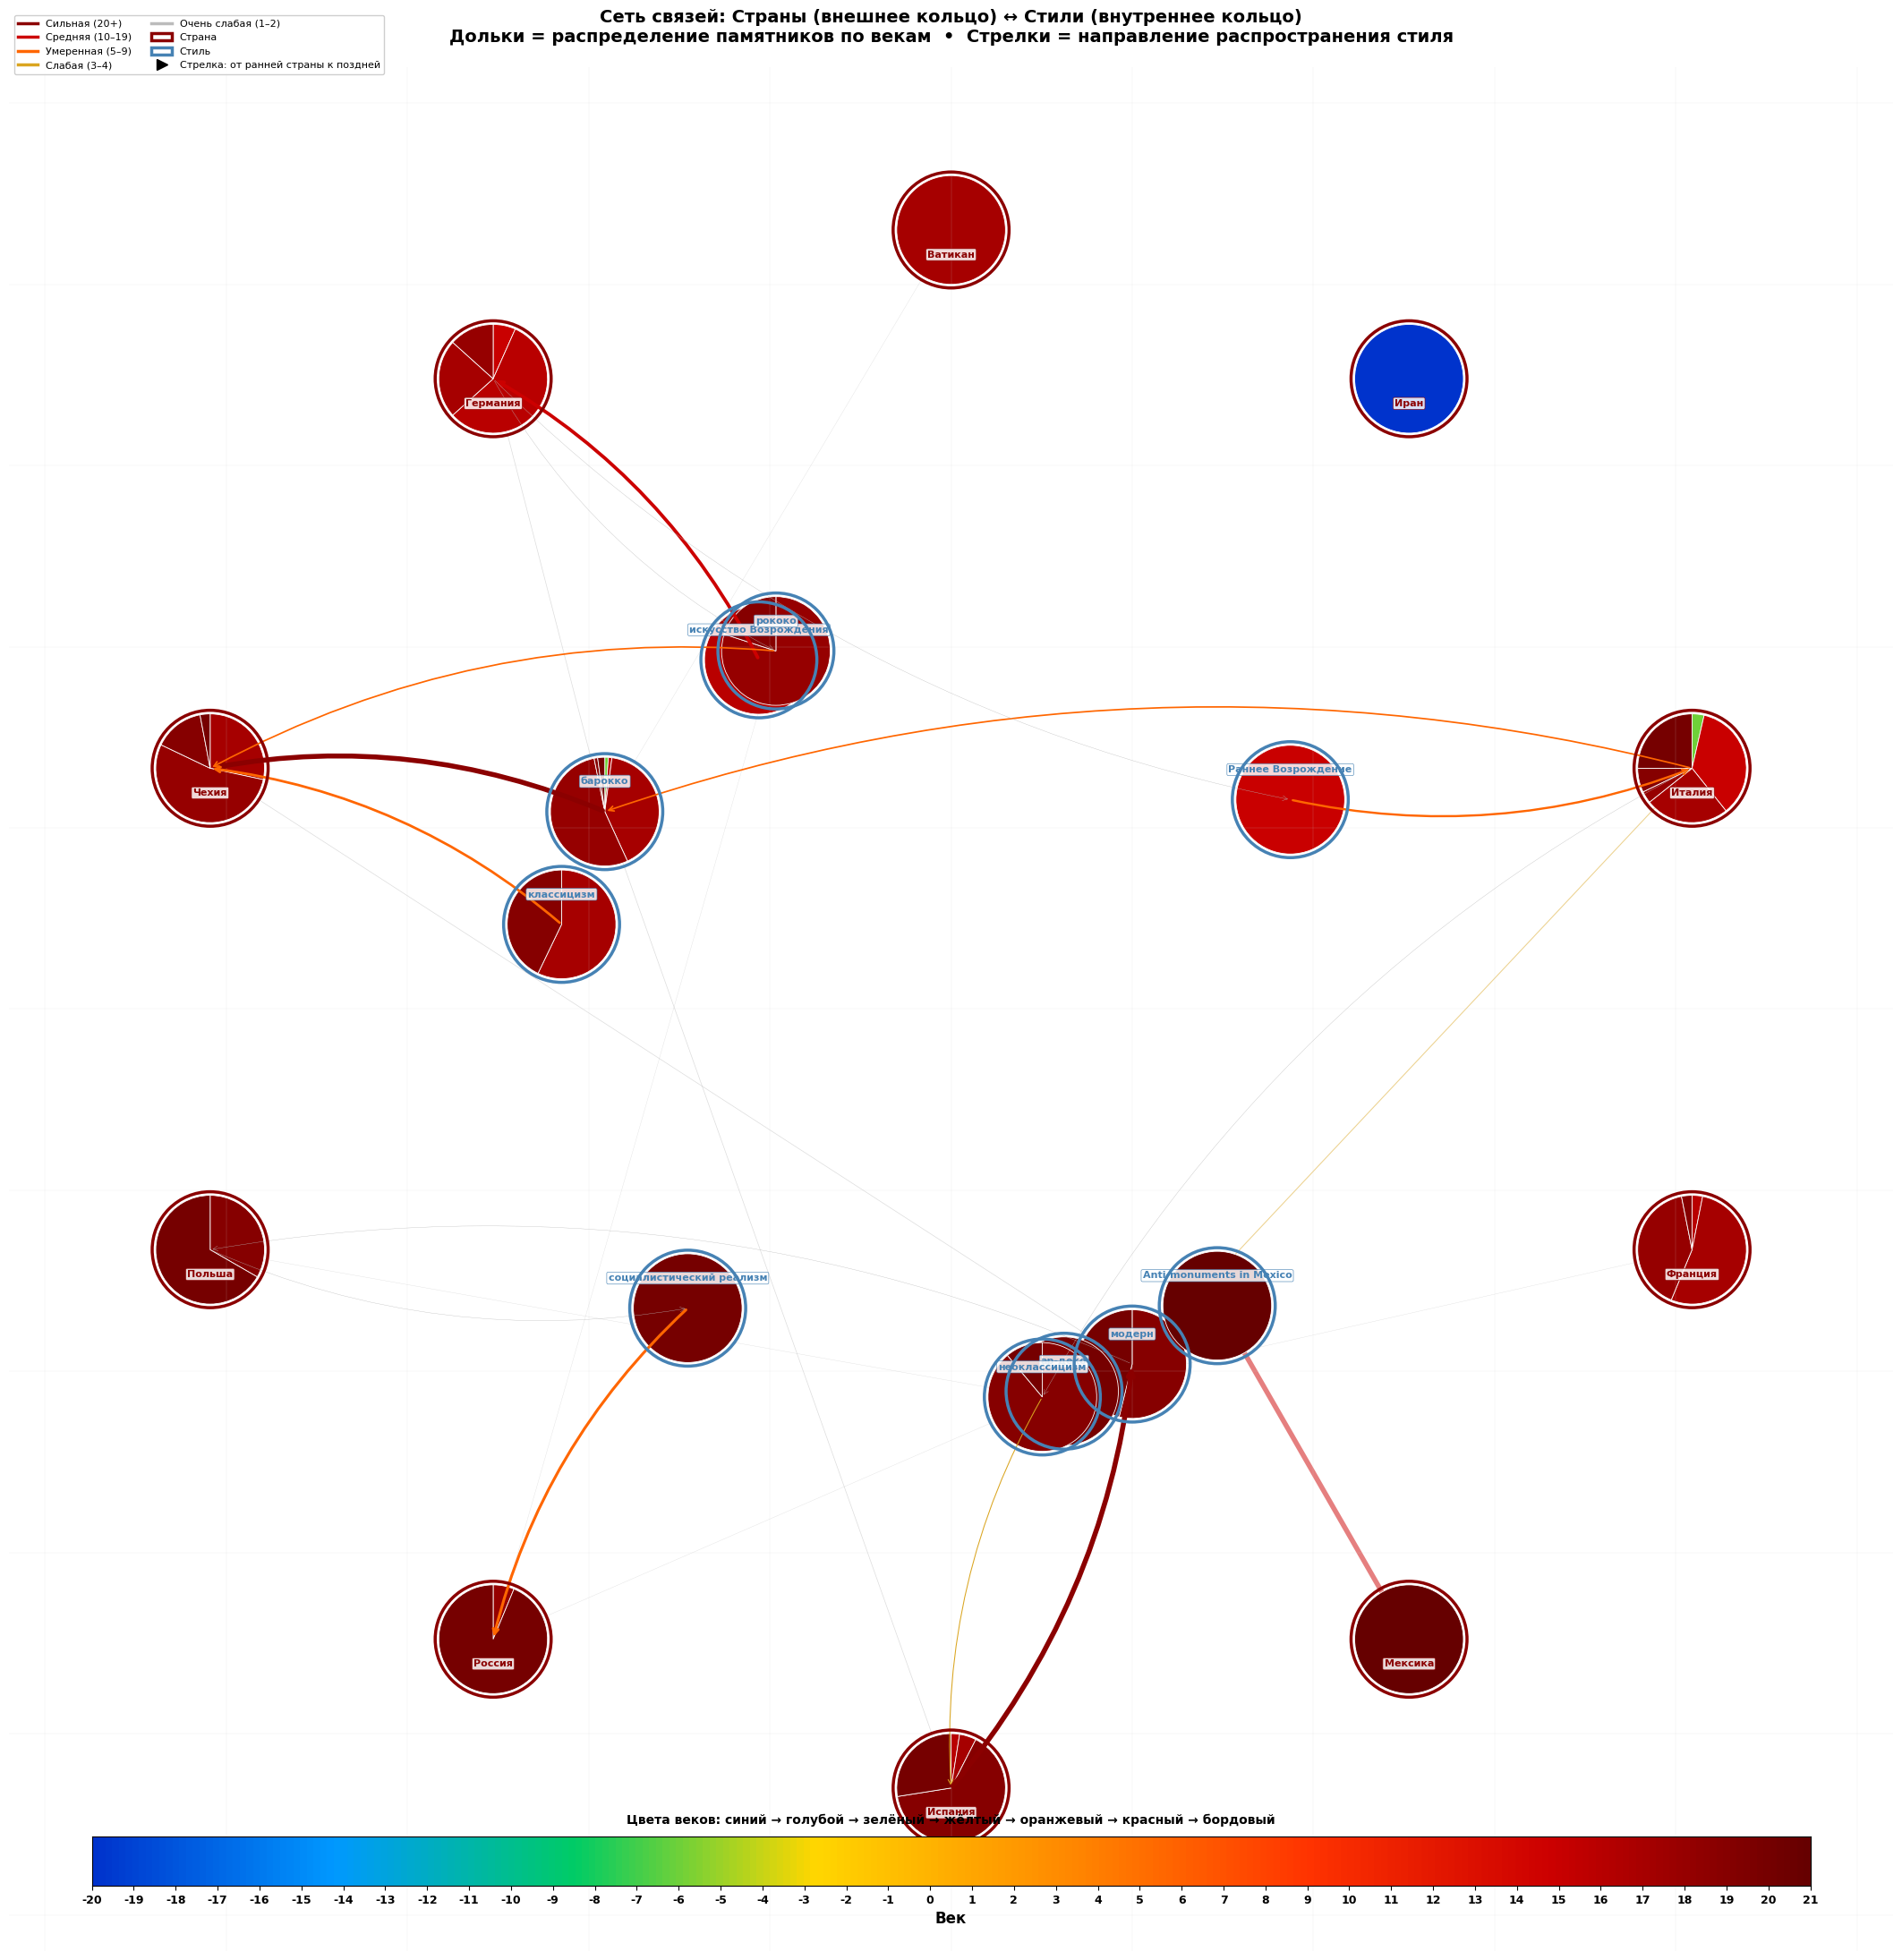


✅ Статическая визуализация сохранена как 'network_static_arrows_pie.png'

🔍 АНАЛИЗ СЕТИ: Ключевые узлы, направления и хронология

📐 СТРУКТУРА ГРАФА:
   • Внешнее кольцо (r=0.43): 10 стран
   • Внутреннее кольцо (r=0.22): 10 стилей
   • Всего рёбер: 24
   • Со стрелками: 8

🎯 НАПРАВЛЕНИЯ РАСПРОСТРАНЕНИЯ СТИЛЕЙ:
   Раннее Возрождение: Германия → Италия
      • Германия: ~15 век
      • Италия: ~15 век
   барокко: Италия → Чехия
      • Италия: ~15 век
      • Испания: ~17 век
      • Ватикан: ~17 век
      • Германия: ~17 век
      • Франция: ~18 век
      • Чехия: ~18 век
   искусство Возрождения: Франция → Германия
      • Франция: ~16 век
      • Германия: ~16 век
   классицизм: Франция → Чехия
      • Франция: ~17 век
      • Испания: ~19 век
      • Чехия: ~19 век
   модерн: Испания → Польша
      • Испания: ~19 век
      • Италия: ~20 век
      • Польша: ~20 век
   неоклассицизм: Италия → Испания
      • Италия: ~19 век
      • Польша: ~19 век
      • Франция: ~19 век
      • Испа

In [9]:
# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("📊 Подготовка данных для сравнительного анализа...")
print(f"✅ Уникальных памятников: {len(df_unique)}")
print(f"✅ Уникальных стран: {df_unique['country'].nunique()}")
print(f"✅ Уникальных стилей: {df_unique['style'].nunique()}")

# ============================================================
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) со стрелками и кружками-дольками
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные с датами
print("\n📅 Загружаем данные с датами памятников...")
df_dates = pd.read_csv("data/monuments_country_style_date.csv")
print(f"✅ Загружено строк с датами: {len(df_dates)}")

# Переименовываем колонки для совместимости
df_dates = df_dates.rename(columns={
    "monument": "URL",
    "monumentLabel": "monument",
    "countryLabel": "country",
    "styleLabel": "style",
    "inceptionYear": "date"
})

# Извлекаем век из даты
def extract_century(date_str):
    if pd.isna(date_str):
        return None
    import re
    if isinstance(date_str, (int, float)):
        year = int(date_str)
    else:
        numbers = re.findall(r'\d{3,4}', str(date_str))
        if not numbers:
            return None
        year = int(numbers[0])
    if year == 0:
        return None
    if year % 100 == 0:
        century = year // 100
    else:
        century = year // 100 + 1
    return century

df_dates['century'] = df_dates['date'].apply(extract_century)
df_dates = df_dates.dropna(subset=['century'])
df_dates['century'] = df_dates['century'].astype(int)

print(f"📊 Памятников с определённым веком: {len(df_dates)}")
print(f"📊 Диапазон веков: {df_dates['century'].min()} – {df_dates['century'].max()}")

# ============================================================
# Топ-10 стран и стилей
# ============================================================
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

print(f"\n🌍 Топ-10 стран: {top10_countries}")
print(f"🎨 Топ-10 стилей: {top10_styles}")

# ============================================================
# ГЕОГРАФИЧЕСКИЕ КООРДИНАТЫ СТРАН (приблизительные)
# ============================================================
country_coords_geo = {
    'Россия':        (0.78, 0.78),
    'Германия':      (0.25, 0.58),
    'Франция':       (0.10, 0.45),
    'Италия':        (0.22, 0.28),
    'Испания':       (0.05, 0.18),
    'Чехия':         (0.32, 0.52),
    'Польша':        (0.48, 0.62),
    'Украина':       (0.62, 0.50),
    'Великобритания':(0.08, 0.65),
    'США':           (0.12, 0.85),
    'Мексика':       (0.08, 0.10),
    'Нидерланды':    (0.16, 0.55),
    'Австрия':       (0.28, 0.40),
    'Бельгия':       (0.12, 0.52),
    'Швейцария':     (0.18, 0.36),
    'Швеция':        (0.38, 0.85),
    'Норвегия':      (0.28, 0.88),
    'Дания':         (0.24, 0.75),
    'Финляндия':     (0.55, 0.88),
    'Греция':        (0.48, 0.12),
    'Турция':        (0.65, 0.08),
    'Япония':        (0.92, 0.48),
    'Китай':         (0.85, 0.38),
    'Индия':         (0.75, 0.18),
    'Бразилия':      (0.22, 0.06),
    'Аргентина':     (0.15, 0.04),
    'Канада':        (0.08, 0.92),
    'Австралия':     (0.90, 0.08),
    'Египет':        (0.58, 0.06),
    'Венгрия':       (0.42, 0.46),
}

def get_country_geo(country):
    if country in country_coords_geo:
        return country_coords_geo[country]
    seed = sum(ord(c) for c in country)
    np.random.seed(seed)
    return (np.random.uniform(0.1, 0.9), np.random.uniform(0.1, 0.9))

# ============================================================
# РАВНОМЕРНОЕ РАСПРЕДЕЛЕНИЕ ВСЕХ УЗЛОВ ПО КРУГОВОЙ СЕТКЕ
# ============================================================

# Всего узлов: 10 стран + 10 стилей = 20 узлов
# Размещаем на 2 кольцах:
#   - Внешнее кольцо (радиус 0.42): страны (10 шт)
#   - Внутреннее кольцо (радиус 0.22): стили (10 шт)
# Сохраняем примерный географический порядок стран

def create_balanced_layout(countries, styles):
    """
    Страны размещаем на внешнем кольце с учётом географии.
    Стили размещаем на внутреннем кольце, оптимизируя связи.
    """
    positions = {}

    # === ВНЕШНЕЕ КОЛЬЦО: СТРАНЫ ===
    # Сортируем страны по географической долготе (восток-запад)
    country_geo = {c: get_country_geo(c) for c in countries}

    # Сортируем страны по X-координате (запад → восток),
    # потом по Y (юг → север) для кольцевого расположения
    sorted_countries = sorted(countries,
        key=lambda c: (country_geo[c][0] + country_geo[c][1] * 0.3))

    n_countries = len(sorted_countries)
    outer_radius = 0.43
    center_x, center_y = 0.50, 0.50

    for i, country in enumerate(sorted_countries):
        # Равномерно распределяем по окружности
        angle = (2 * np.pi * i / n_countries) - np.pi/2  # начинаем сверху
        x = center_x + outer_radius * np.cos(angle)
        y = center_y + outer_radius * np.sin(angle)
        positions[country] = (x, y)

    # === ВНУТРЕННЕЕ КОЛЬЦО: СТИЛИ ===
    # Для каждого стиля находим связанные страны и размещаем ближе к ним
    style_country_map = {}
    for _, row in network_data.iterrows():
        c = row['country']
        s = row['style']
        if c in countries and s in styles:
            if s not in style_country_map:
                style_country_map[s] = []
            style_country_map[s].append(c)

    # Сортируем стили, чтобы связанные шли подряд
    sorted_styles = sorted(styles,
        key=lambda s: np.mean([sorted_countries.index(c) for c in style_country_map.get(s, [sorted_countries[0]])
                              if c in sorted_countries]) if s in style_country_map else 0)

    n_styles = len(sorted_styles)
    inner_radius = 0.22

    for i, style in enumerate(sorted_styles):
        if style in style_country_map and len(style_country_map[style]) > 0:
            # Находим средний угол связанных стран
            linked_countries = [c for c in style_country_map[style] if c in positions]
            if linked_countries:
                angles = []
                for c in linked_countries:
                    dx = positions[c][0] - center_x
                    dy = positions[c][1] - center_y
                    angles.append(np.arctan2(dy, dx))
                avg_angle = np.mean(angles)
            else:
                avg_angle = 2 * np.pi * i / n_styles - np.pi/2
        else:
            avg_angle = 2 * np.pi * i / n_styles - np.pi/2

        # Добавляем небольшой случайный сдвиг для равномерности
        np.random.seed(sum(ord(ch) for ch in style))
        jitter = np.random.uniform(-0.15, 0.15)
        angle = avg_angle + jitter

        x = center_x + inner_radius * np.cos(angle)
        y = center_y + inner_radius * np.sin(angle)
        positions[style] = (x, y)

    return positions

network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

# Получаем сбалансированные позиции
all_positions = create_balanced_layout(top10_countries, top10_styles)
country_pos = {k: v for k, v in all_positions.items() if k in top10_countries}
style_pos = {k: v for k, v in all_positions.items() if k in top10_styles}

# Проверяем минимальные расстояния
print("\n📏 Проверка расстояний между ВСЕМИ узлами:")
min_dist = float('inf')
close_pairs = []
nodes_list = list(all_positions.keys())
for i in range(len(nodes_list)):
    for j in range(i+1, len(nodes_list)):
        p1 = all_positions[nodes_list[i]]
        p2 = all_positions[nodes_list[j]]
        d = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
        if d < min_dist:
            min_dist = d
        if d < 0.06:
            close_pairs.append((nodes_list[i], nodes_list[j], d))
            print(f"   ⚠️ Близко: {nodes_list[i]} — {nodes_list[j]}: d={d:.3f}")

print(f"   Минимальное расстояние: {min_dist:.3f}")

# ============================================================
# ОПРЕДЕЛЕНИЕ НАПРАВЛЕНИЯ СТРЕЛОК
# ============================================================
print("\n🔍 Определяем направления распространения стилей по датам...")

df_network_dates = df_dates[
    df_dates['country'].isin(top10_countries) &
    df_dates['style'].isin(top10_styles)
].copy()

style_country_century = df_network_dates.groupby(['style', 'country'])['century'].mean().reset_index()
style_country_century.columns = ['style', 'country', 'avg_century']

style_centuries = defaultdict(dict)
for _, row in style_country_century.iterrows():
    style_centuries[row['style']][row['country']] = row['avg_century']

style_directions = {}
for style, country_centuries in style_centuries.items():
    if len(country_centuries) >= 2:
        sorted_countries = sorted(country_centuries.items(), key=lambda x: x[1])
        style_directions[style] = {
            'earliest': sorted_countries[0][0],
            'latest': sorted_countries[-1][0],
            'centuries': country_centuries
        }
        print(f"   {style}: {sorted_countries[0][0]} ({sorted_countries[0][1]:.1f} в.) → {sorted_countries[-1][0]} ({sorted_countries[-1][1]:.1f} в.)")
    elif len(country_centuries) == 1:
        style_directions[style] = {
            'earliest': list(country_centuries.keys())[0],
            'latest': list(country_centuries.keys())[0],
            'centuries': country_centuries
        }

# ============================================================
# ЦВЕТОВАЯ ШКАЛА — КОНТРАСТНАЯ
# ============================================================
min_century = int(df_dates['century'].min())
max_century = int(df_dates['century'].max())

print(f"\n🎨 Цветовая шкала: {min_century}–{max_century} века")

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

colors_list = [
    (0.0,   '#0033CC'),   # синий (ранние)
    (0.14,  '#0099FF'),   # голубой
    (0.28,  '#00CC66'),   # зелёный
    (0.42,  '#FFD700'),   # жёлтый
    (0.57,  '#FF8800'),   # оранжевый
    (0.71,  '#FF3300'),   # красно-оранжевый
    (0.85,  '#CC0000'),   # красный
    (1.0,   '#660000'),   # бордовый (поздние)
]

cmap = LinearSegmentedColormap.from_list('contrast_centuries', colors_list, N=256)

def century_to_color(century):
    if century is None or pd.isna(century):
        return 'lightgray'
    norm = (century - min_century) / max(1, (max_century - min_century))
    return mcolors.to_hex(cmap(norm))

# ============================================================
# ДАННЫЕ ДЛЯ КРУЖКОВ-ДОЛЕК
# ============================================================
country_century_dist = {}
for country in top10_countries:
    country_data = df_dates[
        (df_dates['country'] == country) &
        (df_dates['style'].isin(top10_styles))
    ]
    century_counts = country_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        country_century_dist[country] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        country_century_dist[country] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

style_century_dist = {}
for style in top10_styles:
    style_data = df_dates[
        (df_dates['style'] == style) &
        (df_dates['country'].isin(top10_countries))
    ]
    century_counts = style_data['century'].value_counts().sort_index()
    if len(century_counts) > 0:
        style_century_dist[style] = {
            'centuries': century_counts.index.tolist(),
            'counts': century_counts.values.tolist(),
            'total': century_counts.sum()
        }
    else:
        style_century_dist[style] = {
            'centuries': [min_century],
            'counts': [1],
            'total': 1
        }

# ============================================================
# РИСУЕМ ГРАФ
# ============================================================
print("\n🎨 Рисуем финальную визуализацию...")

fig, ax = plt.subplots(1, 1, figsize=(24, 22))
ax.set_facecolor('#FAFAFA')

# Тонкая сетка
for val in np.arange(0, 1.01, 0.1):
    ax.axvline(val, color='lightgray', linewidth=0.3, alpha=0.4)
    ax.axhline(val, color='lightgray', linewidth=0.3, alpha=0.4)

# ==== РЁБРА ====
edge_data = []
for _, row in network_data.iterrows():
    country = row['country']
    style = row['style']
    if country in country_pos and style in style_pos:
        edge_data.append((country, style))

edge_weights = Counter(edge_data)

def get_edge_color(weight):
    if weight >= 20:   return '#8B0000'
    elif weight >= 10: return '#CC0000'
    elif weight >= 5:  return '#FF6600'
    elif weight >= 3:  return '#DAA520'
    else:              return '#BBBBBB'

drawn_edges = set()
for (country, style), weight in edge_weights.items():
    if (country, style) in drawn_edges or (style, country) in drawn_edges:
        continue
    drawn_edges.add((country, style))

    x1, y1 = country_pos[country]
    x2, y2 = style_pos[style]

    color = get_edge_color(weight)
    lw = min(weight / 4, 4)

    # Направление стрелки
    is_directed = False
    arrow_direction = None

    if style in style_directions:
        dir_info = style_directions[style]
        if dir_info['earliest'] != dir_info['latest']:
            is_directed = True
            if country == dir_info['earliest']:
                arrow_direction = 'from_country_to_style'
            elif country == dir_info['latest']:
                arrow_direction = 'from_style_to_country'

    if is_directed and arrow_direction == 'from_country_to_style':
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.15'))
    elif is_directed and arrow_direction == 'from_style_to_country':
        ax.annotate('', xy=(x1, y1), xytext=(x2, y2),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.15'))
    else:
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=lw, alpha=0.5, zorder=1)

# ==== КРУЖКИ-ДОЛЬКИ: СТРАНЫ ====
country_pie_radius = 0.030

for country in top10_countries:
    cx, cy = country_pos[country]
    dist = country_century_dist[country]

    if dist['total'] > 0:
        ax.pie(
            dist['counts'],
            radius=country_pie_radius,
            center=(cx, cy),
            colors=[century_to_color(c) for c in dist['centuries']],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=0.6)
        )

    # Обводка
    circle = plt.Circle((cx, cy), country_pie_radius + 0.002, fill=False,
                        edgecolor='darkred', linewidth=2.5, zorder=5)
    ax.add_patch(circle)

    # Подпись
    ax.annotate(country, (cx, cy),
                textcoords="offset points", xytext=(0, -22),
                ha='center', fontsize=8, fontweight='bold', color='darkred',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                         alpha=0.85, edgecolor='darkred', linewidth=0.5))

# ==== КРУЖКИ-ДОЛЬКИ: СТИЛИ ====
style_pie_radius = 0.030

for style in top10_styles:
    sx, sy = style_pos[style]
    dist = style_century_dist[style]

    if dist['total'] > 0:
        ax.pie(
            dist['counts'],
            radius=style_pie_radius,
            center=(sx, sy),
            colors=[century_to_color(c) for c in dist['centuries']],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=0.6)
        )

    # Обводка
    circle = plt.Circle((sx, sy), style_pie_radius + 0.002, fill=False,
                        edgecolor='steelblue', linewidth=2.5, zorder=5)
    ax.add_patch(circle)

    # Подпись
    ax.annotate(style, (sx, sy),
                textcoords="offset points", xytext=(0, 22),
                ha='center', fontsize=8, fontweight='bold', color='steelblue',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                         alpha=0.85, edgecolor='steelblue', linewidth=0.5))

# ==== ЦВЕТОВАЯ ШКАЛА ====
gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient = np.vstack((gradient, gradient))

ax_colorbar = fig.add_axes([0.10, 0.04, 0.80, 0.025])
ax_colorbar.imshow(gradient, aspect='auto', cmap=cmap,
                   extent=[min_century, max_century, 0, 1])
ax_colorbar.set_yticks([])

all_centuries = list(range(min_century, max_century + 1))
ax_colorbar.set_xticks(all_centuries)
ax_colorbar.set_xticklabels([str(c) for c in all_centuries],
                            fontsize=9, fontweight='bold')
ax_colorbar.set_xlabel('Век', fontsize=12, fontweight='bold')
ax_colorbar.set_title(
    'Цвета веков: синий → голубой → зелёный → жёлтый → оранжевый → красный → бордовый',
    fontsize=10, pad=10, fontweight='bold')

# ==== ЛЕГЕНДА ====
legend_elements = [
    Line2D([0], [0], color='#8B0000', lw=2.5, label='Сильная (20+)'),
    Line2D([0], [0], color='#CC0000', lw=2.5, label='Средняя (10–19)'),
    Line2D([0], [0], color='#FF6600', lw=2.5, label='Умеренная (5–9)'),
    Line2D([0], [0], color='#DAA520', lw=2.5, label='Слабая (3–4)'),
    Line2D([0], [0], color='#BBBBBB', lw=2.5, label='Очень слабая (1–2)'),
    mpatches.Patch(facecolor='white', edgecolor='darkred', linewidth=2.5, label='Страна'),
    mpatches.Patch(facecolor='white', edgecolor='steelblue', linewidth=2.5, label='Стиль'),
    Line2D([0], [0], marker='>', color='black', lw=0, markerfacecolor='black',
           markersize=8, label='Стрелка: от ранней страны к поздней'),
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=8,
          framealpha=0.95, ncol=2, bbox_to_anchor=(0.0, 1.03))

# ==== ЗАГОЛОВОК ====
ax.set_title(
    "Сеть связей: Страны (внешнее кольцо) ↔ Стили (внутреннее кольцо)\n"
    "Дольки = распределение памятников по векам  •  Стрелки = направление распространения стиля",
    fontsize=14, fontweight='bold', pad=20
)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig('network_static_arrows_pie.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Статическая визуализация сохранена как 'network_static_arrows_pie.png'")

# ============================================================
# ВЫВОД АНАЛИЗА
# ============================================================
print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Ключевые узлы, направления и хронология")
print("="*80)

print(f"\n📐 СТРУКТУРА ГРАФА:")
print(f"   • Внешнее кольцо (r=0.43): {len(top10_countries)} стран")
print(f"   • Внутреннее кольцо (r=0.22): {len(top10_styles)} стилей")
print(f"   • Всего рёбер: {len(edge_weights)}")
print(f"   • Со стрелками: {sum(1 for s in style_directions if style_directions[s]['earliest'] != style_directions[s]['latest'])}")

print("\n🎯 НАПРАВЛЕНИЯ РАСПРОСТРАНЕНИЯ СТИЛЕЙ:")
for style, dir_info in style_directions.items():
    if dir_info['earliest'] != dir_info['latest']:
        print(f"   {style}: {dir_info['earliest']} → {dir_info['latest']}")
        for country, century in sorted(dir_info['centuries'].items(), key=lambda x: x[1]):
            print(f"      • {country}: ~{century:.0f} век")